In [16]:
# =====================================================================
# 03_forecasting_preparation.ipynb
# Historical Time Series Analysis of Air Raid Alerts in Ukraine
# Step 3: Leakage-free forecasting dataset preparation
# =====================================================================

from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
from IPython.display import display


# ---------------------------------------------------------------------
# 1. Find project root and src/
# ---------------------------------------------------------------------

current_dir = Path.cwd().resolve()

if (current_dir / "src").exists():
    PROJECT_ROOT = current_dir

elif (current_dir.parent / "src").exists():
    PROJECT_ROOT = current_dir.parent

else:
    raise FileNotFoundError(
        "Project root was not found.\n"
        "Expected a folder named 'src' in the current directory "
        "or its parent directory.\n"
        f"Current working directory: {current_dir}"
    )

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


# ---------------------------------------------------------------------
# 2. Load current configuration
# ---------------------------------------------------------------------

if "config" in sys.modules:
    del sys.modules["config"]

importlib.invalidate_caches()

import config

print("=" * 78)
print("FORECAST CONFIGURATION")
print("=" * 78)

print(f"Loaded config from: {config.__file__}")

DAILY_REGION_METRICS_FILE = config.DAILY_REGION_METRICS_FILE
FORECAST_FEATURES_FILE = config.FORECAST_FEATURES_FILE
FORECAST_TRAIN_FILE = config.FORECAST_TRAIN_FILE
FORECAST_TEST_FILE = config.FORECAST_TEST_FILE

FORECAST_REGION = config.FORECAST_REGION
FORECAST_TARGET_COLUMN = config.FORECAST_TARGET_COLUMN
FORECAST_LAGS = config.FORECAST_LAGS
FORECAST_ROLLING_WINDOWS = config.FORECAST_ROLLING_WINDOWS
FORECAST_TEST_SIZE_DAYS = config.FORECAST_TEST_SIZE_DAYS


# ---------------------------------------------------------------------
# 3. Load daily metrics
# ---------------------------------------------------------------------

print("\n" + "=" * 78)
print("DAILY METRICS LOADING")
print("=" * 78)

if not DAILY_REGION_METRICS_FILE.exists():
    raise FileNotFoundError(
        "Daily metrics CSV was not found.\n"
        f"Expected file: {DAILY_REGION_METRICS_FILE}"
    )

daily_metrics = pd.read_csv(
    DAILY_REGION_METRICS_FILE,
    parse_dates=["date"],
)

required_columns = [
    "date",
    "region",
    FORECAST_TARGET_COLUMN,
]

missing_columns = [
    column
    for column in required_columns
    if column not in daily_metrics.columns
]

if missing_columns:
    raise KeyError(
        "Daily metrics are missing required columns:\n"
        f"{missing_columns}\n\n"
        f"Available columns:\n{daily_metrics.columns.tolist()}"
    )

print("✅ Daily metrics loaded successfully.")
print(
    f"Shape: {daily_metrics.shape[0]:,} rows × "
    f"{daily_metrics.shape[1]} columns"
)


# ---------------------------------------------------------------------
# 4. Extract daily target series for Kyiv City
# ---------------------------------------------------------------------

kyiv_daily = (
    daily_metrics.loc[
        daily_metrics["region"].eq(FORECAST_REGION),
        ["date", FORECAST_TARGET_COLUMN],
    ]
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

if kyiv_daily.empty:
    raise ValueError(
        f"No daily data found for forecast region: {FORECAST_REGION}"
    )

if kyiv_daily["date"].duplicated().any():
    duplicate_count = int(
        kyiv_daily["date"].duplicated().sum()
    )

    raise ValueError(
        "Duplicate dates were found for the forecast region. "
        f"Duplicate count: {duplicate_count}"
    )

kyiv_daily[FORECAST_TARGET_COLUMN] = pd.to_numeric(
    kyiv_daily[FORECAST_TARGET_COLUMN],
    errors="coerce",
)

if kyiv_daily[FORECAST_TARGET_COLUMN].isna().any():
    invalid_count = int(
        kyiv_daily[FORECAST_TARGET_COLUMN].isna().sum()
    )

    raise ValueError(
        "Target column contains invalid values. "
        f"Invalid count: {invalid_count}"
    )

if (kyiv_daily[FORECAST_TARGET_COLUMN] < 0).any():
    raise ValueError(
        "Target column contains negative durations."
    )

expected_dates = pd.date_range(
    start=kyiv_daily["date"].min(),
    end=kyiv_daily["date"].max(),
    freq="D",
)

actual_dates = pd.DatetimeIndex(
    kyiv_daily["date"]
)

if not actual_dates.equals(expected_dates):
    missing_day_count = len(expected_dates) - len(actual_dates)

    raise ValueError(
        "Kyiv City daily time series is not continuous. "
        f"Estimated missing-day count: {missing_day_count}"
    )

print("\n" + "=" * 78)
print("FORECAST TARGET SERIES")
print("=" * 78)

print(f"Forecast region: {FORECAST_REGION}")
print(f"Daily rows before feature creation: {len(kyiv_daily):,}")
print(
    f"Date range: {kyiv_daily['date'].min().date()} "
    f"to {kyiv_daily['date'].max().date()}"
)

display(kyiv_daily.head())


# ---------------------------------------------------------------------
# 5. Create lag, rolling, and calendar features
# ---------------------------------------------------------------------

forecast_features = (
    kyiv_daily
    .rename(
        columns={
            FORECAST_TARGET_COLUMN: "target",
        }
    )
    .set_index("date")
    .copy()
)

# Lag features: values known before the current day.
for lag in FORECAST_LAGS:
    forecast_features[f"lag_{lag}"] = (
        forecast_features["target"]
        .shift(lag)
    )

# Rolling features are shifted by one day first.
# This prevents current-day target leakage into features.
for window in FORECAST_ROLLING_WINDOWS:
    forecast_features[f"rolling_mean_{window}"] = (
        forecast_features["target"]
        .shift(1)
        .rolling(
            window=window,
            min_periods=window,
        )
        .mean()
    )

# Seasonal Naive baseline:
# prediction for day t = actual value from day t - 7.
forecast_features["seasonal_naive_prediction"] = (
    forecast_features["lag_7"]
)

# Calendar features are known in advance.
forecast_features["day_of_week"] = (
    forecast_features.index.dayofweek
)

forecast_features["is_weekend"] = (
    forecast_features["day_of_week"]
    .isin([5, 6])
    .astype(int)
)

forecast_features["month"] = (
    forecast_features.index.month
)

forecast_features["day_of_week_sin"] = np.sin(
    2 * np.pi * forecast_features["day_of_week"] / 7
)

forecast_features["day_of_week_cos"] = np.cos(
    2 * np.pi * forecast_features["day_of_week"] / 7
)

forecast_features["month_sin"] = np.sin(
    2 * np.pi * forecast_features["month"] / 12
)

forecast_features["month_cos"] = np.cos(
    2 * np.pi * forecast_features["month"] / 12
)

feature_columns = [
    *[
        f"lag_{lag}"
        for lag in FORECAST_LAGS
    ],
    *[
        f"rolling_mean_{window}"
        for window in FORECAST_ROLLING_WINDOWS
    ],
    "day_of_week",
    "is_weekend",
    "month",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
]

required_model_columns = [
    "target",
    "seasonal_naive_prediction",
    *feature_columns,
]

forecast_dataset = (
    forecast_features
    .dropna(
        subset=required_model_columns,
    )
    .reset_index()
)

if forecast_dataset.empty:
    raise ValueError(
        "Feature dataset is empty after lag and rolling-feature creation."
    )

if forecast_dataset[required_model_columns].isna().any().any():
    raise ValueError(
        "Unexpected missing values remain in forecast dataset."
    )

if not np.allclose(
    forecast_dataset["seasonal_naive_prediction"],
    forecast_dataset["lag_7"],
):
    raise ValueError(
        "Seasonal Naive baseline does not match lag_7 values."
    )

print("\n" + "=" * 78)
print("FORECAST FEATURE DATASET")
print("=" * 78)

print(f"Rows after feature creation: {len(forecast_dataset):,}")
print(f"Number of model features: {len(feature_columns)}")

print("\nFeature columns:")
for feature_name in feature_columns:
    print(f"  - {feature_name}")

print("\nFirst valid feature date:")
print(forecast_dataset['date'].min().date())

display(forecast_dataset.head())


# ---------------------------------------------------------------------
# 6. Chronological train-test split
# ---------------------------------------------------------------------

if len(forecast_dataset) <= FORECAST_TEST_SIZE_DAYS:
    raise ValueError(
        "Forecast dataset is too short for the configured test period.\n"
        f"Rows available: {len(forecast_dataset)}\n"
        f"Required test rows: {FORECAST_TEST_SIZE_DAYS}"
    )

train_data = (
    forecast_dataset
    .iloc[:-FORECAST_TEST_SIZE_DAYS]
    .copy()
)

test_data = (
    forecast_dataset
    .iloc[-FORECAST_TEST_SIZE_DAYS:]
    .copy()
)

if train_data["date"].max() >= test_data["date"].min():
    raise ValueError(
        "Chronological split failed: training and test dates overlap."
    )

print("\n" + "=" * 78)
print("CHRONOLOGICAL TRAIN-TEST SPLIT")
print("=" * 78)

print(f"Training rows: {len(train_data):,}")
print(f"Test rows: {len(test_data):,}")

print(
    f"Training range: "
    f"{train_data['date'].min().date()} "
    f"to {train_data['date'].max().date()}"
)

print(
    f"Test range: "
    f"{test_data['date'].min().date()} "
    f"to {test_data['date'].max().date()}"
)


# ---------------------------------------------------------------------
# 7. Save reproducible feature datasets
# ---------------------------------------------------------------------

config.PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

forecast_dataset.to_csv(
    FORECAST_FEATURES_FILE,
    index=False,
)

train_data.to_csv(
    FORECAST_TRAIN_FILE,
    index=False,
)

test_data.to_csv(
    FORECAST_TEST_FILE,
    index=False,
)

assert FORECAST_FEATURES_FILE.exists()
assert FORECAST_TRAIN_FILE.exists()
assert FORECAST_TEST_FILE.exists()

print("\n" + "=" * 78)
print("FORECAST DATASET SAVED SUCCESSFULLY")
print("=" * 78)

print(f"All features: {FORECAST_FEATURES_FILE}")
print(f"Training data: {FORECAST_TRAIN_FILE}")
print(f"Test data: {FORECAST_TEST_FILE}")

print("\n✅ Leakage-free forecasting dataset preparation completed.")

FORECAST CONFIGURATION
Loaded config from: D:\it10\PythonProject2\src\config.py

DAILY METRICS LOADING
✅ Daily metrics loaded successfully.
Shape: 33,925 rows × 6 columns

FORECAST TARGET SERIES
Forecast region: Kyiv City
Daily rows before feature creation: 1,357
Date range: 2022-03-15 to 2025-11-30


,date,total_duration_min
0,2022-03-15,153.133333
1,2022-03-16,799.533333
2,2022-03-17,405.916667
3,2022-03-18,430.333333
4,2022-03-19,336.883333



FORECAST FEATURE DATASET
Rows after feature creation: 1,329
Number of model features: 13

Feature columns:
  - lag_1
  - lag_7
  - lag_14
  - rolling_mean_7
  - rolling_mean_14
  - rolling_mean_28
  - day_of_week
  - is_weekend
  - month
  - day_of_week_sin
  - day_of_week_cos
  - month_sin
  - month_cos

First valid feature date:
2022-04-12


,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,rolling_mean_28,seasonal_naive_prediction,day_of_week,is_weekend,month,day_of_week_sin,day_of_week_cos,month_sin,month_cos
0,2022-04-12,90.800000,99.450000,119.233333,549.783333,84.247619,182.714286,321.283929,119.233333,1,0,4,0.781831,0.623490,0.866025,-0.5
1,2022-04-13,12.316667,90.800000,44.883333,369.433333,80.185714,149.929762,319.057738,44.883333,2,0,4,0.974928,-0.222521,0.866025,-0.5
2,2022-04-14,260.150000,12.316667,90.766667,167.133333,75.533333,124.421429,290.942857,90.766667,3,0,4,0.433884,-0.900969,0.866025,-0.5
3,2022-04-15,274.016667,260.150000,104.283333,71.416667,99.730952,131.065476,285.736905,104.283333,4,0,4,-0.433884,-0.900969,0.866025,-0.5
4,2022-04-16,250.166667,274.016667,57.183333,267.050000,123.978571,145.536905,280.154167,57.183333,5,1,4,-0.974928,-0.222521,0.866025,-0.5



CHRONOLOGICAL TRAIN-TEST SPLIT
Training rows: 1,149
Test rows: 180
Training range: 2022-04-12 to 2025-06-03
Test range: 2025-06-04 to 2025-11-30

FORECAST DATASET SAVED SUCCESSFULLY
All features: D:\it10\PythonProject2\data\processed\kyiv_city_forecast_features.csv
Training data: D:\it10\PythonProject2\data\processed\kyiv_city_forecast_train.csv
Test data: D:\it10\PythonProject2\data\processed\kyiv_city_forecast_test.csv

✅ Leakage-free forecasting dataset preparation completed.


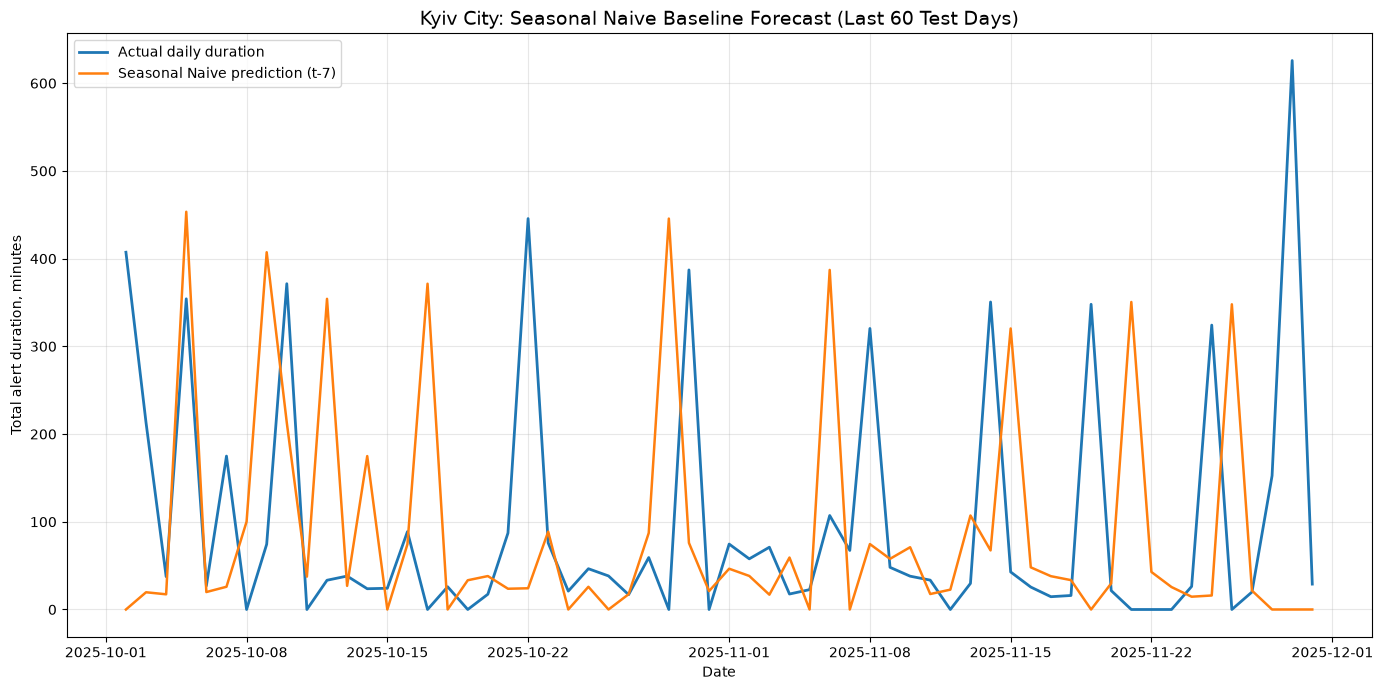

SEASONAL NAIVE BASELINE RESULT
Test period: 2025-06-04 to 2025-11-30
Test observations: 180
Zero-duration days in test: 28

Forecast metrics:


,model,forecast_region,test_start_date,test_end_date,test_rows,mae_min,rmse_min,smape_percent,zero_duration_days_in_test
0,Seasonal Naive (lag 7),Kyiv City,2025-06-04,2025-11-30,180,134.345,198.484,124.905,28



First 10 baseline predictions:

First 10 baseline predictions:


,date,actual_duration_min,seasonal_naive_duration_min,absolute_error_min,squared_error_min2,smape_component
0,2025-06-04,28.73,82.12,53.38,2849.78,0.96
1,2025-06-05,21.03,0.00,21.03,442.40,2.00
2,2025-06-06,248.22,0.00,248.22,61611.51,2.00
3,2025-06-07,37.73,27.87,9.87,97.35,0.30
4,2025-06-08,74.25,641.03,566.78,321243.35,1.58
5,2025-06-09,362.48,47.43,315.05,99256.50,1.54
6,2025-06-10,359.95,85.02,274.93,75588.34,1.24
7,2025-06-11,12.68,28.73,16.05,257.60,0.78
8,2025-06-12,0.00,21.03,21.03,442.40,2.00
9,2025-06-13,0.00,248.22,248.22,61611.51,2.00



Files created:
  D:\it10\PythonProject2\reports\seasonal_naive_test_predictions.csv
  D:\it10\PythonProject2\reports\forecast_metrics.csv
  D:\it10\PythonProject2\reports\figures\06_kyiv_city_seasonal_naive_baseline.png

✅ Seasonal Naive baseline was evaluated successfully.


In [17]:
# =====================================================================
# Seasonal Naive baseline evaluation for Kyiv City
# =====================================================================

import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import config

importlib.reload(config)

REPORTS_DIR = config.REPORTS_DIR
FORECAST_METRICS_FILE = config.FORECAST_METRICS_FILE
FORECAST_TEST_SIZE_DAYS = config.FORECAST_TEST_SIZE_DAYS


# ---------------------------------------------------------------------
# 1. Validate that the chronological test dataset is available
# ---------------------------------------------------------------------

required_test_columns = [
    "date",
    "target",
    "seasonal_naive_prediction",
]

if "test_data" not in globals():
    raise NameError(
        "test_data was not found in the notebook memory.\n"
        "Run the first forecasting-preparation cell first."
    )

missing_columns = [
    column
    for column in required_test_columns
    if column not in test_data.columns
]

if missing_columns:
    raise KeyError(
        "test_data is missing required columns:\n"
        f"{missing_columns}\n\n"
        f"Available columns:\n{test_data.columns.tolist()}"
    )

if len(test_data) != FORECAST_TEST_SIZE_DAYS:
    raise ValueError(
        "Unexpected number of test rows.\n"
        f"Expected: {FORECAST_TEST_SIZE_DAYS}\n"
        f"Received: {len(test_data)}"
    )


# ---------------------------------------------------------------------
# 2. Prepare actual values and Seasonal Naive predictions
# ---------------------------------------------------------------------

baseline_evaluation = (
    test_data[
        [
            "date",
            "target",
            "seasonal_naive_prediction",
        ]
    ]
    .copy()
    .rename(
        columns={
            "target": "actual_duration_min",
            "seasonal_naive_prediction": (
                "seasonal_naive_duration_min"
            ),
        }
    )
    .sort_values("date")
    .reset_index(drop=True)
)

prediction_columns = [
    "actual_duration_min",
    "seasonal_naive_duration_min",
]

if baseline_evaluation[prediction_columns].isna().any().any():
    raise ValueError(
        "Missing actual values or Seasonal Naive predictions "
        "were found in the test dataset."
    )

if not np.isfinite(
    baseline_evaluation[prediction_columns].to_numpy()
).all():
    raise ValueError(
        "Non-finite values were found in the baseline evaluation data."
    )

if (baseline_evaluation[prediction_columns] < 0).any().any():
    raise ValueError(
        "Negative durations were found in the baseline evaluation data."
    )


# ---------------------------------------------------------------------
# 3. Calculate forecast errors and metrics
# ---------------------------------------------------------------------

baseline_evaluation["absolute_error_min"] = (
    baseline_evaluation["actual_duration_min"]
    - baseline_evaluation["seasonal_naive_duration_min"]
).abs()

baseline_evaluation["squared_error_min2"] = (
    baseline_evaluation["actual_duration_min"]
    - baseline_evaluation["seasonal_naive_duration_min"]
) ** 2

smape_denominator = (
    baseline_evaluation["actual_duration_min"].abs()
    + baseline_evaluation["seasonal_naive_duration_min"].abs()
)

baseline_evaluation["smape_component"] = np.where(
    smape_denominator.eq(0),
    0.0,
    (
        2
        * baseline_evaluation["absolute_error_min"]
        / smape_denominator
    ),
)

mae = baseline_evaluation["absolute_error_min"].mean()

rmse = np.sqrt(
    baseline_evaluation["squared_error_min2"].mean()
)

smape_percent = (
    baseline_evaluation["smape_component"].mean()
    * 100
)

zero_duration_days = int(
    baseline_evaluation["actual_duration_min"].eq(0).sum()
)

metrics_table = pd.DataFrame(
    [
        {
            "model": "Seasonal Naive (lag 7)",
            "forecast_region": config.FORECAST_REGION,
            "test_start_date": baseline_evaluation["date"].min().date(),
            "test_end_date": baseline_evaluation["date"].max().date(),
            "test_rows": len(baseline_evaluation),
            "mae_min": mae,
            "rmse_min": rmse,
            "smape_percent": smape_percent,
            "zero_duration_days_in_test": zero_duration_days,
        }
    ]
)


# ---------------------------------------------------------------------
# 4. Save baseline predictions and metrics
# ---------------------------------------------------------------------

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

baseline_predictions_path = (
    REPORTS_DIR
    / "seasonal_naive_test_predictions.csv"
)

baseline_evaluation.to_csv(
    baseline_predictions_path,
    index=False,
)

metrics_table.to_csv(
    FORECAST_METRICS_FILE,
    index=False,
)


# ---------------------------------------------------------------------
# 5. Plot the final 60 days of the test period
# ---------------------------------------------------------------------

plot_days = 60

plot_data = baseline_evaluation.tail(plot_days)

baseline_figure_path = (
    config.FIGURES_DIR
    / "06_kyiv_city_seasonal_naive_baseline.png"
)

config.FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

figure, axes = plt.subplots(
    figsize=(14, 7),
)

axes.plot(
    plot_data["date"],
    plot_data["actual_duration_min"],
    label="Actual daily duration",
    linewidth=2,
)

axes.plot(
    plot_data["date"],
    plot_data["seasonal_naive_duration_min"],
    label="Seasonal Naive prediction (t-7)",
    linewidth=1.8,
)

axes.set_title(
    "Kyiv City: Seasonal Naive Baseline Forecast "
    "(Last 60 Test Days)",
    fontsize=14,
)

axes.set_xlabel("Date")
axes.set_ylabel("Total alert duration, minutes")

axes.grid(
    True,
    alpha=0.3,
)

axes.legend()

figure.tight_layout()

figure.savefig(
    baseline_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------------
# 6. Output and checks
# ---------------------------------------------------------------------

print("=" * 78)
print("SEASONAL NAIVE BASELINE RESULT")
print("=" * 78)

print(
    f"Test period: "
    f"{baseline_evaluation['date'].min().date()} "
    f"to {baseline_evaluation['date'].max().date()}"
)

print(f"Test observations: {len(baseline_evaluation):,}")
print(f"Zero-duration days in test: {zero_duration_days:,}")

print("\nForecast metrics:")
metrics_preview = metrics_table.copy()

numeric_columns = metrics_preview.select_dtypes(
    include="number"
).columns

metrics_preview[numeric_columns] = (
    metrics_preview[numeric_columns]
    .round(3)
)

display(metrics_preview)

print("\nFirst 10 baseline predictions:")
print("\nFirst 10 baseline predictions:")

baseline_preview = baseline_evaluation.head(10).copy()

numeric_columns = baseline_preview.select_dtypes(
    include="number"
).columns

baseline_preview[numeric_columns] = (
    baseline_preview[numeric_columns]
    .round(2)
)

display(baseline_preview)

assert len(baseline_evaluation) == FORECAST_TEST_SIZE_DAYS
assert baseline_evaluation["date"].is_monotonic_increasing
assert baseline_evaluation["absolute_error_min"].ge(0).all()
assert baseline_predictions_path.exists()
assert FORECAST_METRICS_FILE.exists()
assert baseline_figure_path.exists()

print("\nFiles created:")
print(f"  {baseline_predictions_path}")
print(f"  {FORECAST_METRICS_FILE}")
print(f"  {baseline_figure_path}")

print("\n✅ Seasonal Naive baseline was evaluated successfully.")

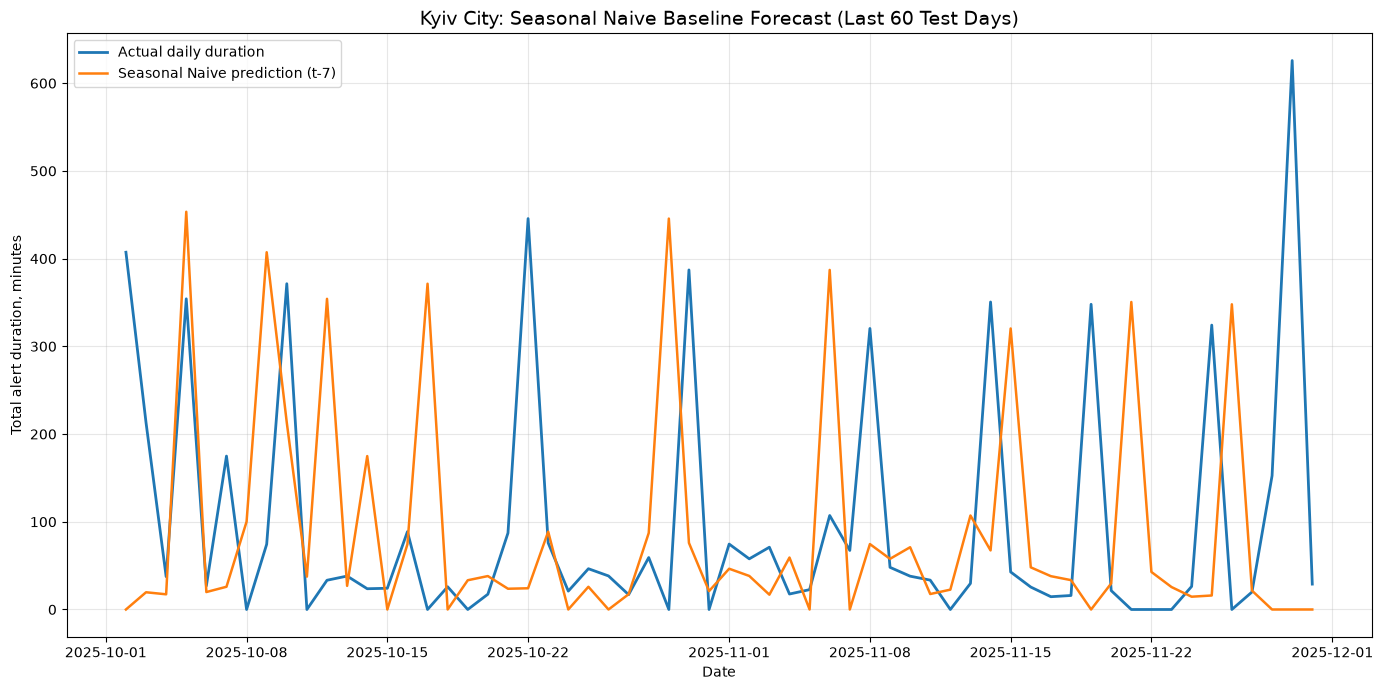

REUSABLE SEASONAL NAIVE BASELINE RESULT


,model,forecast_region,test_start_date,test_end_date,test_rows,mae_min,rmse_min,smape_percent,zero_duration_days_in_test
0,Seasonal Naive (lag 7),Kyiv City,2025-06-04,2025-11-30,180,134.345,198.484,124.905,28



Files created:
  D:\it10\PythonProject2\reports\seasonal_naive_test_predictions.csv
  D:\it10\PythonProject2\reports\forecast_metrics.csv
  D:\it10\PythonProject2\reports\figures\06_kyiv_city_seasonal_naive_baseline.png

✅ Reusable Seasonal Naive baseline works correctly.


In [18]:
# =====================================================================
# Reusable Seasonal Naive baseline evaluation
# =====================================================================

import importlib

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import config
import forecasting

importlib.reload(config)
importlib.reload(forecasting)

from forecasting import (
    evaluate_seasonal_naive_baseline,
    plot_seasonal_naive_baseline,
)


# ---------------------------------------------------------------------
# Load stored test data
# ---------------------------------------------------------------------

FORECAST_TEST_FILE = config.FORECAST_TEST_FILE
FORECAST_METRICS_FILE = config.FORECAST_METRICS_FILE
FORECAST_REGION = config.FORECAST_REGION
REPORTS_DIR = config.REPORTS_DIR
FIGURES_DIR = config.FIGURES_DIR

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

test_data_script = pd.read_csv(
    FORECAST_TEST_FILE,
    parse_dates=["date"],
)


# ---------------------------------------------------------------------
# Evaluate baseline with reusable script
# ---------------------------------------------------------------------

baseline_evaluation_script, baseline_metrics_script = (
    evaluate_seasonal_naive_baseline(
        test_data=test_data_script,
        forecast_region=FORECAST_REGION,
    )
)

baseline_predictions_path = (
    REPORTS_DIR
    / "seasonal_naive_test_predictions.csv"
)

baseline_figure_path = (
    FIGURES_DIR
    / "06_kyiv_city_seasonal_naive_baseline.png"
)

baseline_evaluation_script.to_csv(
    baseline_predictions_path,
    index=False,
)

baseline_metrics_script.to_csv(
    FORECAST_METRICS_FILE,
    index=False,
)


# ---------------------------------------------------------------------
# Create reusable comparison plot
# ---------------------------------------------------------------------

figure, axes = plot_seasonal_naive_baseline(
    baseline_evaluation=baseline_evaluation_script,
    output_path=baseline_figure_path,
    plot_days=60,
)

plt.show()


# ---------------------------------------------------------------------
# Output and validation
# ---------------------------------------------------------------------

print("=" * 78)
print("REUSABLE SEASONAL NAIVE BASELINE RESULT")
print("=" * 78)

metrics_preview = baseline_metrics_script.copy()

numeric_columns = metrics_preview.select_dtypes(
    include="number"
).columns

metrics_preview[numeric_columns] = (
    metrics_preview[numeric_columns]
    .round(3)
)

display(metrics_preview)

assert len(baseline_evaluation_script) == 180
assert baseline_predictions_path.exists()
assert FORECAST_METRICS_FILE.exists()
assert baseline_figure_path.exists()

print("\nFiles created:")
print(f"  {baseline_predictions_path}")
print(f"  {FORECAST_METRICS_FILE}")
print(f"  {baseline_figure_path}")

print("\n✅ Reusable Seasonal Naive baseline works correctly.")

RIDGE REGRESSION DATA CHECK
Forecast region: Kyiv City
Training rows: 1,149
Test rows: 180
Number of model features: 13
Training range: 2022-04-12 to 2025-06-03
Test range: 2025-06-04 to 2025-11-30

Model features:
  - lag_1
  - lag_7
  - lag_14
  - rolling_mean_7
  - rolling_mean_14
  - rolling_mean_28
  - day_of_week
  - is_weekend
  - month
  - day_of_week_sin
  - day_of_week_cos
  - month_sin
  - month_cos

RIDGE TIME-SERIES VALIDATION
Validation splits: 5
Best alpha: 1000.0
Best mean validation MAE: 79.700 minutes


,alpha,mean_validation_mae_min,validation_mae_std_min,mean_training_mae_min
0,1000.00,79.700,11.549,72.346
1,100.00,80.647,13.798,70.885
2,10.00,83.238,16.964,70.401
3,1.00,89.745,27.395,70.146
4,0.10,99.667,45.909,70.070
5,0.01,101.300,49.055,70.063


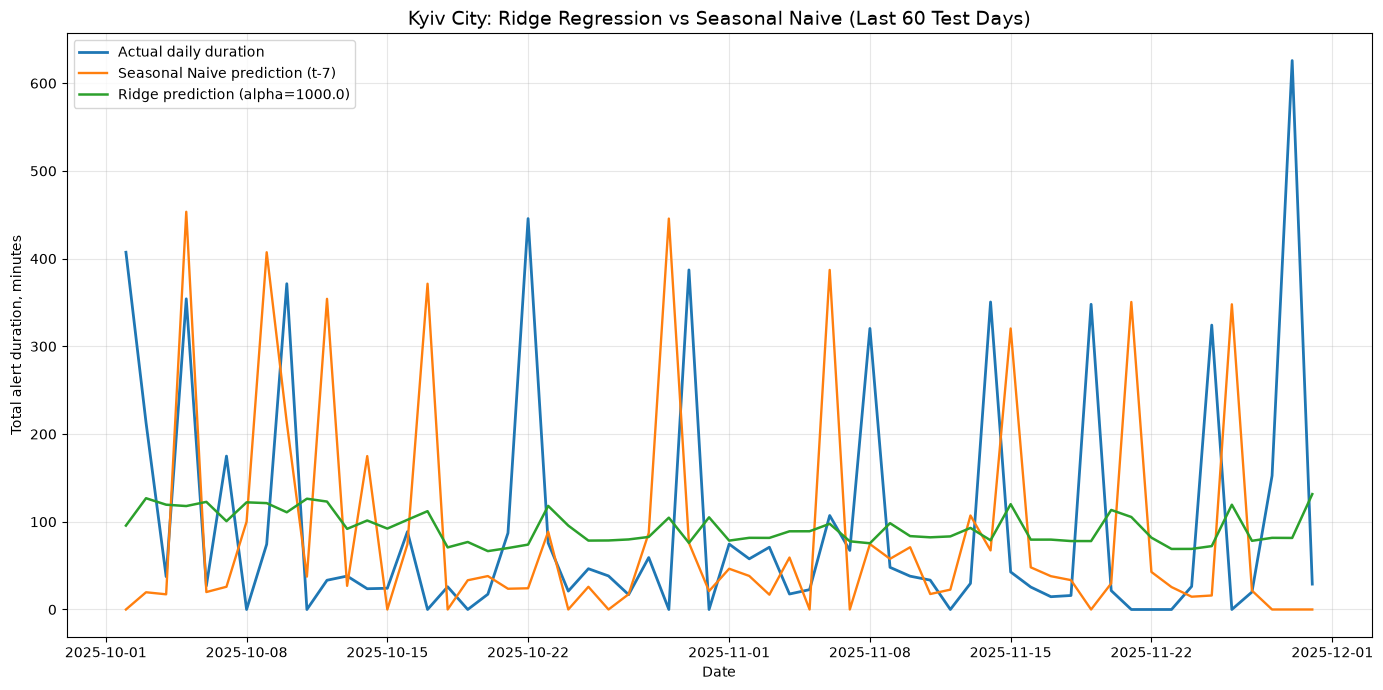


RIDGE REGRESSION TEST RESULT


,model,forecast_region,test_start_date,test_end_date,test_rows,mae_min,rmse_min,smape_percent,zero_duration_days_in_test,negative_raw_predictions_clipped_to_zero
0,Ridge Regression (alpha=1000.0),Kyiv City,2025-06-04,2025-11-30,180,111.104,150.887,106.666,28,0
1,Seasonal Naive (lag 7),Kyiv City,2025-06-04,2025-11-30,180,134.345,198.484,124.905,28,0



Most influential standardized Ridge coefficients:


,feature,standardized_coefficient,absolute_coefficient
0,rolling_mean_14,9.4779,9.4779
1,rolling_mean_7,8.6143,8.6143
2,rolling_mean_28,7.4105,7.4105
3,lag_1,6.9497,6.9497
4,lag_7,5.2464,5.2464
5,month_cos,2.0987,2.0987
6,lag_14,2.0252,2.0252
7,day_of_week_cos,-1.7152,1.7152
8,is_weekend,-0.9295,0.9295
9,month_sin,0.8642,0.8642



Raw negative Ridge predictions clipped to zero: 0

Files created:
  D:\it10\PythonProject2\reports\ridge_test_predictions.csv
  D:\it10\PythonProject2\reports\ridge_feature_coefficients.csv
  D:\it10\PythonProject2\reports\forecast_metrics.csv
  D:\it10\PythonProject2\reports\figures\07_kyiv_city_ridge_vs_baseline.png

✅ Ridge Regression was trained and compared with Seasonal Naive successfully.


In [19]:
# =====================================================================
# Ridge Regression forecast:
# training, time-series validation and comparison with baseline
# =====================================================================

import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import config
import forecasting

importlib.reload(config)
importlib.reload(forecasting)

from forecasting import (
    calculate_forecast_metrics,
    evaluate_seasonal_naive_baseline,
)


# ---------------------------------------------------------------------
# 1. Load configuration and stored chronological datasets
# ---------------------------------------------------------------------

FORECAST_TRAIN_FILE = config.FORECAST_TRAIN_FILE
FORECAST_TEST_FILE = config.FORECAST_TEST_FILE

FORECAST_METRICS_FILE = config.FORECAST_METRICS_FILE
RIDGE_TEST_PREDICTIONS_FILE = config.RIDGE_TEST_PREDICTIONS_FILE
RIDGE_FEATURE_COEFFICIENTS_FILE = config.RIDGE_FEATURE_COEFFICIENTS_FILE

FORECAST_REGION = config.FORECAST_REGION
FORECAST_LAGS = config.FORECAST_LAGS
FORECAST_ROLLING_WINDOWS = config.FORECAST_ROLLING_WINDOWS
FORECAST_TEST_SIZE_DAYS = config.FORECAST_TEST_SIZE_DAYS

RIDGE_ALPHA_CANDIDATES = config.RIDGE_ALPHA_CANDIDATES
RIDGE_TIME_SERIES_SPLITS = config.RIDGE_TIME_SERIES_SPLITS

REPORTS_DIR = config.REPORTS_DIR
FIGURES_DIR = config.FIGURES_DIR

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if not FORECAST_TRAIN_FILE.exists():
    raise FileNotFoundError(
        "Training forecast dataset was not found.\n"
        f"Expected file: {FORECAST_TRAIN_FILE}"
    )

if not FORECAST_TEST_FILE.exists():
    raise FileNotFoundError(
        "Test forecast dataset was not found.\n"
        f"Expected file: {FORECAST_TEST_FILE}"
    )

train_data_ridge = pd.read_csv(
    FORECAST_TRAIN_FILE,
    parse_dates=["date"],
)

test_data_ridge = pd.read_csv(
    FORECAST_TEST_FILE,
    parse_dates=["date"],
)


# ---------------------------------------------------------------------
# 2. Reconstruct the exact 13 model features
# ---------------------------------------------------------------------

feature_columns = [
    *[
        f"lag_{lag}"
        for lag in FORECAST_LAGS
    ],
    *[
        f"rolling_mean_{window}"
        for window in FORECAST_ROLLING_WINDOWS
    ],
    "day_of_week",
    "is_weekend",
    "month",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
]

required_columns = [
    "date",
    "target",
    "seasonal_naive_prediction",
    *feature_columns,
]

missing_train_columns = [
    column
    for column in required_columns
    if column not in train_data_ridge.columns
]

missing_test_columns = [
    column
    for column in required_columns
    if column not in test_data_ridge.columns
]

if missing_train_columns:
    raise KeyError(
        "Training data is missing required columns:\n"
        f"{missing_train_columns}"
    )

if missing_test_columns:
    raise KeyError(
        "Test data is missing required columns:\n"
        f"{missing_test_columns}"
    )

if len(test_data_ridge) != FORECAST_TEST_SIZE_DAYS:
    raise ValueError(
        "Unexpected number of test rows.\n"
        f"Expected: {FORECAST_TEST_SIZE_DAYS}\n"
        f"Received: {len(test_data_ridge)}"
    )

if train_data_ridge["date"].max() >= test_data_ridge["date"].min():
    raise ValueError(
        "Training and test periods overlap."
    )

numeric_columns = [
    "target",
    *feature_columns,
]

for dataframe_name, dataframe in [
    ("train_data_ridge", train_data_ridge),
    ("test_data_ridge", test_data_ridge),
]:
    if dataframe[numeric_columns].isna().any().any():
        raise ValueError(
            f"{dataframe_name} contains missing values "
            "in target or feature columns."
        )

    if not np.isfinite(
        dataframe[numeric_columns].to_numpy()
    ).all():
        raise ValueError(
            f"{dataframe_name} contains non-finite values."
        )

print("=" * 78)
print("RIDGE REGRESSION DATA CHECK")
print("=" * 78)

print(f"Forecast region: {FORECAST_REGION}")
print(f"Training rows: {len(train_data_ridge):,}")
print(f"Test rows: {len(test_data_ridge):,}")
print(f"Number of model features: {len(feature_columns)}")

print(
    f"Training range: "
    f"{train_data_ridge['date'].min().date()} "
    f"to {train_data_ridge['date'].max().date()}"
)

print(
    f"Test range: "
    f"{test_data_ridge['date'].min().date()} "
    f"to {test_data_ridge['date'].max().date()}"
)

print("\nModel features:")
for feature_name in feature_columns:
    print(f"  - {feature_name}")


# ---------------------------------------------------------------------
# 3. Prepare train and test matrices
# ---------------------------------------------------------------------

X_train = train_data_ridge[feature_columns].copy()
y_train = train_data_ridge["target"].copy()

X_test = test_data_ridge[feature_columns].copy()
y_test = test_data_ridge["target"].copy()


# ---------------------------------------------------------------------
# 4. Select Ridge alpha using chronological validation splits
# ---------------------------------------------------------------------

time_series_cv = TimeSeriesSplit(
    n_splits=RIDGE_TIME_SERIES_SPLITS,
)

ridge_pipeline = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "ridge",
            Ridge(),
        ),
    ]
)

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid={
        "ridge__alpha": RIDGE_ALPHA_CANDIDATES,
    },
    scoring="neg_mean_absolute_error",
    cv=time_series_cv,
    refit=True,
    return_train_score=True,
)

ridge_search.fit(
    X_train,
    y_train,
)

best_ridge_model = ridge_search.best_estimator_
best_alpha = ridge_search.best_params_["ridge__alpha"]
best_validation_mae = -ridge_search.best_score_

cv_results = (
    pd.DataFrame(ridge_search.cv_results_)
    .loc[
        :,
        [
            "param_ridge__alpha",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
        ],
    ]
    .copy()
)

cv_results = cv_results.rename(
    columns={
        "param_ridge__alpha": "alpha",
        "mean_test_score": "mean_validation_mae_negative",
        "std_test_score": "validation_mae_std_negative",
        "mean_train_score": "mean_training_mae_negative",
    }
)

cv_results["mean_validation_mae_min"] = (
    -cv_results["mean_validation_mae_negative"]
)

cv_results["validation_mae_std_min"] = (
    cv_results["validation_mae_std_negative"].abs()
)

cv_results["mean_training_mae_min"] = (
    -cv_results["mean_training_mae_negative"]
)

cv_results = (
    cv_results
    .sort_values("mean_validation_mae_min")
    .reset_index(drop=True)
)

print("\n" + "=" * 78)
print("RIDGE TIME-SERIES VALIDATION")
print("=" * 78)

print(f"Validation splits: {RIDGE_TIME_SERIES_SPLITS}")
print(f"Best alpha: {best_alpha}")
print(
    f"Best mean validation MAE: "
    f"{best_validation_mae:.3f} minutes"
)

display(
    cv_results[
        [
            "alpha",
            "mean_validation_mae_min",
            "validation_mae_std_min",
            "mean_training_mae_min",
        ]
    ].round(3)
)


# ---------------------------------------------------------------------
# 5. Make Ridge predictions for the same 180 test days
# ---------------------------------------------------------------------

ridge_raw_predictions = best_ridge_model.predict(
    X_test
)

# Duration cannot be negative. This post-processing changes only
# impossible negative predictions to zero.
ridge_predictions = np.clip(
    ridge_raw_predictions,
    a_min=0,
    a_max=None,
)

ridge_evaluation = pd.DataFrame(
    {
        "date": test_data_ridge["date"].to_numpy(),
        "actual_duration_min": y_test.to_numpy(),
        "ridge_raw_prediction_min": ridge_raw_predictions,
        "ridge_duration_min": ridge_predictions,
    }
)

ridge_evaluation["absolute_error_min"] = (
    ridge_evaluation["actual_duration_min"]
    - ridge_evaluation["ridge_duration_min"]
).abs()

ridge_evaluation["squared_error_min2"] = (
    ridge_evaluation["actual_duration_min"]
    - ridge_evaluation["ridge_duration_min"]
) ** 2

smape_denominator = (
    ridge_evaluation["actual_duration_min"].abs()
    + ridge_evaluation["ridge_duration_min"].abs()
)

ridge_evaluation["smape_component"] = np.where(
    smape_denominator.eq(0),
    0.0,
    2
    * ridge_evaluation["absolute_error_min"]
    / smape_denominator,
)

ridge_metrics = calculate_forecast_metrics(
    actual_values=ridge_evaluation["actual_duration_min"],
    predicted_values=ridge_evaluation["ridge_duration_min"],
)

negative_raw_prediction_count = int(
    (ridge_evaluation["ridge_raw_prediction_min"] < 0).sum()
)

ridge_metrics_table = pd.DataFrame(
    [
        {
            "model": (
                f"Ridge Regression "
                f"(alpha={best_alpha})"
            ),
            "forecast_region": FORECAST_REGION,
            "test_start_date": ridge_evaluation["date"].min().date(),
            "test_end_date": ridge_evaluation["date"].max().date(),
            "test_rows": len(ridge_evaluation),
            "mae_min": ridge_metrics["mae_min"],
            "rmse_min": ridge_metrics["rmse_min"],
            "smape_percent": ridge_metrics["smape_percent"],
            "zero_duration_days_in_test": int(
                ridge_evaluation["actual_duration_min"]
                .eq(0)
                .sum()
            ),
            "negative_raw_predictions_clipped_to_zero": (
                negative_raw_prediction_count
            ),
        }
    ]
)


# ---------------------------------------------------------------------
# 6. Recalculate baseline on the same stored test data
# ---------------------------------------------------------------------

baseline_evaluation_ridge, baseline_metrics_ridge = (
    evaluate_seasonal_naive_baseline(
        test_data=test_data_ridge,
        forecast_region=FORECAST_REGION,
    )
)

baseline_metrics_ridge[
    "negative_raw_predictions_clipped_to_zero"
] = 0

comparison_metrics = pd.concat(
    [
        baseline_metrics_ridge,
        ridge_metrics_table,
    ],
    ignore_index=True,
)

comparison_metrics = comparison_metrics.sort_values(
    by="mae_min",
    ascending=True,
).reset_index(drop=True)


# ---------------------------------------------------------------------
# 7. Prepare standardized Ridge coefficient table
# ---------------------------------------------------------------------

ridge_coefficients = (
    pd.DataFrame(
        {
            "feature": feature_columns,
            "standardized_coefficient": (
                best_ridge_model
                .named_steps["ridge"]
                .coef_
            ),
        }
    )
)

ridge_coefficients["absolute_coefficient"] = (
    ridge_coefficients["standardized_coefficient"]
    .abs()
)

ridge_coefficients = (
    ridge_coefficients
    .sort_values(
        "absolute_coefficient",
        ascending=False,
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# 8. Save predictions, model comparison and coefficients
# ---------------------------------------------------------------------

baseline_predictions_path = (
    REPORTS_DIR
    / "seasonal_naive_test_predictions.csv"
)

comparison_figure_path = (
    FIGURES_DIR
    / "07_kyiv_city_ridge_vs_baseline.png"
)

ridge_evaluation.to_csv(
    RIDGE_TEST_PREDICTIONS_FILE,
    index=False,
)

baseline_evaluation_ridge.to_csv(
    baseline_predictions_path,
    index=False,
)

comparison_metrics.to_csv(
    FORECAST_METRICS_FILE,
    index=False,
)

ridge_coefficients.to_csv(
    RIDGE_FEATURE_COEFFICIENTS_FILE,
    index=False,
)


# ---------------------------------------------------------------------
# 9. Plot actual values, baseline and Ridge predictions
# ---------------------------------------------------------------------

plot_days = 60

comparison_plot_data = (
    ridge_evaluation
    .tail(plot_days)
    .merge(
        baseline_evaluation_ridge[
            [
                "date",
                "seasonal_naive_duration_min",
            ]
        ],
        on="date",
        how="left",
        validate="one_to_one",
    )
)

if comparison_plot_data[
    "seasonal_naive_duration_min"
].isna().any():
    raise ValueError(
        "Baseline predictions could not be aligned "
        "with Ridge test dates."
    )

figure, axes = plt.subplots(
    figsize=(14, 7),
)

axes.plot(
    comparison_plot_data["date"],
    comparison_plot_data["actual_duration_min"],
    label="Actual daily duration",
    linewidth=2,
)

axes.plot(
    comparison_plot_data["date"],
    comparison_plot_data["seasonal_naive_duration_min"],
    label="Seasonal Naive prediction (t-7)",
    linewidth=1.7,
)

axes.plot(
    comparison_plot_data["date"],
    comparison_plot_data["ridge_duration_min"],
    label=f"Ridge prediction (alpha={best_alpha})",
    linewidth=1.8,
)

axes.set_title(
    "Kyiv City: Ridge Regression vs Seasonal Naive "
    f"(Last {plot_days} Test Days)",
    fontsize=14,
)

axes.set_xlabel("Date")
axes.set_ylabel("Total alert duration, minutes")

axes.grid(
    True,
    alpha=0.3,
)

axes.legend()

figure.tight_layout()

figure.savefig(
    comparison_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------------
# 10. Output and final checks
# ---------------------------------------------------------------------

print("\n" + "=" * 78)
print("RIDGE REGRESSION TEST RESULT")
print("=" * 78)

metrics_preview = comparison_metrics.copy()

numeric_columns = metrics_preview.select_dtypes(
    include="number"
).columns

metrics_preview[numeric_columns] = (
    metrics_preview[numeric_columns]
    .round(3)
)

display(metrics_preview)

print("\nMost influential standardized Ridge coefficients:")
display(
    ridge_coefficients
    .head(10)
    .round(4)
)

print(
    f"\nRaw negative Ridge predictions clipped to zero: "
    f"{negative_raw_prediction_count}"
)

assert len(ridge_evaluation) == FORECAST_TEST_SIZE_DAYS

assert ridge_evaluation["date"].equals(
    baseline_evaluation_ridge["date"]
)

assert (
    ridge_evaluation["ridge_duration_min"] >= 0
).all()

assert set(comparison_metrics["model"]) == {
    "Seasonal Naive (lag 7)",
    f"Ridge Regression (alpha={best_alpha})",
}

assert RIDGE_TEST_PREDICTIONS_FILE.exists()
assert RIDGE_FEATURE_COEFFICIENTS_FILE.exists()
assert FORECAST_METRICS_FILE.exists()
assert comparison_figure_path.exists()

print("\nFiles created:")
print(f"  {RIDGE_TEST_PREDICTIONS_FILE}")
print(f"  {RIDGE_FEATURE_COEFFICIENTS_FILE}")
print(f"  {FORECAST_METRICS_FILE}")
print(f"  {comparison_figure_path}")

print(
    "\n✅ Ridge Regression was trained and compared "
    "with Seasonal Naive successfully."
)

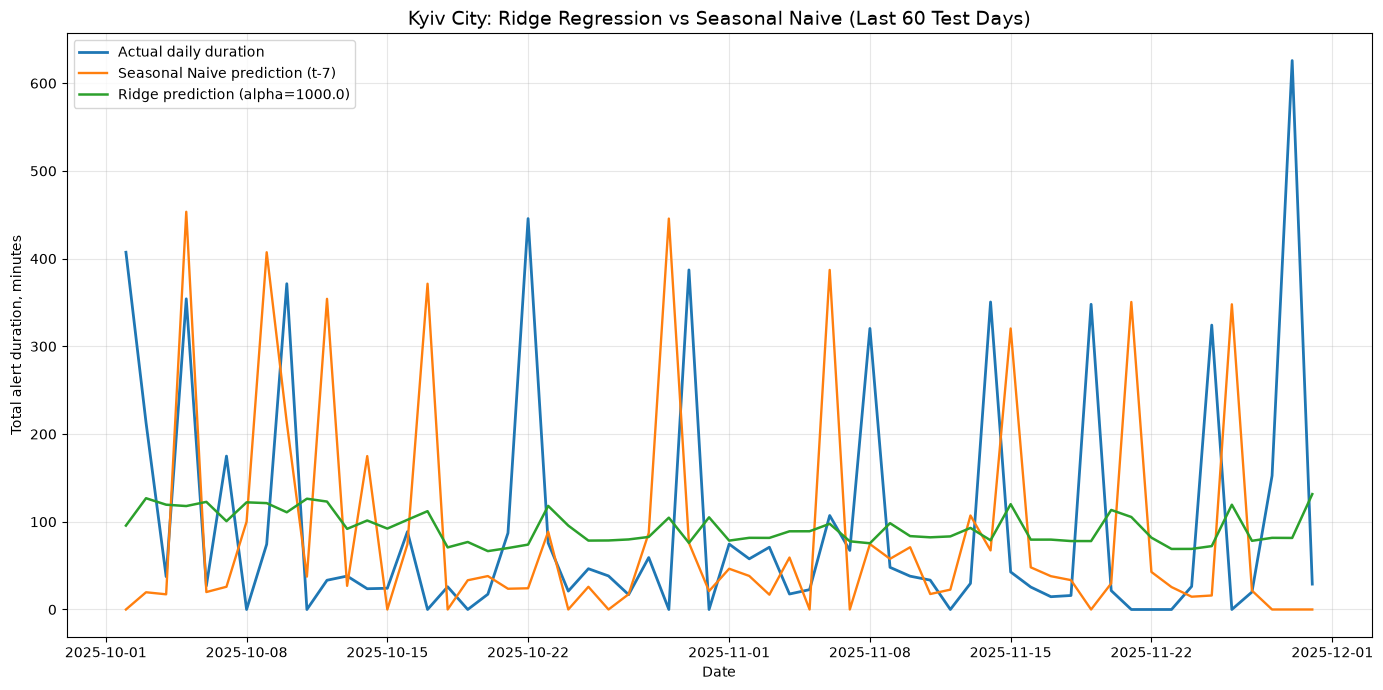

REUSABLE RIDGE REGRESSION RESULT
Best alpha: 1000.0

Ridge time-series validation:


,alpha,mean_validation_mae_min,validation_mae_std_min,mean_training_mae_min
0,1000.00,79.700,11.549,72.346
1,100.00,80.647,13.798,70.885
2,10.00,83.238,16.964,70.401
3,1.00,89.745,27.395,70.146
4,0.10,99.667,45.909,70.070
5,0.01,101.300,49.055,70.063



Final test comparison:


,model,forecast_region,test_start_date,test_end_date,test_rows,mae_min,rmse_min,smape_percent,zero_duration_days_in_test,negative_raw_predictions_clipped_to_zero
0,Ridge Regression (alpha=1000.0),Kyiv City,2025-06-04,2025-11-30,180,111.104,150.887,106.666,28,0
1,Seasonal Naive (lag 7),Kyiv City,2025-06-04,2025-11-30,180,134.345,198.484,124.905,28,0



Most influential standardized Ridge coefficients:


,feature,standardized_coefficient,absolute_coefficient
0,rolling_mean_14,9.4779,9.4779
1,rolling_mean_7,8.6143,8.6143
2,rolling_mean_28,7.4105,7.4105
3,lag_1,6.9497,6.9497
4,lag_7,5.2464,5.2464
5,month_cos,2.0987,2.0987
6,lag_14,2.0252,2.0252
7,day_of_week_cos,-1.7152,1.7152
8,is_weekend,-0.9295,0.9295
9,month_sin,0.8642,0.8642



Files created:
  D:\it10\PythonProject2\reports\ridge_test_predictions.csv
  D:\it10\PythonProject2\reports\ridge_feature_coefficients.csv
  D:\it10\PythonProject2\reports\forecast_metrics.csv
  D:\it10\PythonProject2\reports\figures\07_kyiv_city_ridge_vs_baseline.png

✅ Reusable Ridge Regression training and comparison work correctly.


In [20]:
# =====================================================================
# Reusable Ridge Regression training and comparison with baseline
# =====================================================================

import importlib

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import config
import forecasting

importlib.reload(config)
importlib.reload(forecasting)

from forecasting import (
    evaluate_seasonal_naive_baseline,
    plot_ridge_vs_baseline,
    train_and_evaluate_ridge_regression,
)


# ---------------------------------------------------------------------
# 1. Load configuration and stored chronological datasets
# ---------------------------------------------------------------------

FORECAST_TRAIN_FILE = config.FORECAST_TRAIN_FILE
FORECAST_TEST_FILE = config.FORECAST_TEST_FILE

FORECAST_METRICS_FILE = config.FORECAST_METRICS_FILE
RIDGE_TEST_PREDICTIONS_FILE = config.RIDGE_TEST_PREDICTIONS_FILE
RIDGE_FEATURE_COEFFICIENTS_FILE = (
    config.RIDGE_FEATURE_COEFFICIENTS_FILE
)

FORECAST_REGION = config.FORECAST_REGION
FORECAST_LAGS = config.FORECAST_LAGS
FORECAST_ROLLING_WINDOWS = config.FORECAST_ROLLING_WINDOWS

RIDGE_ALPHA_CANDIDATES = config.RIDGE_ALPHA_CANDIDATES
RIDGE_TIME_SERIES_SPLITS = config.RIDGE_TIME_SERIES_SPLITS

REPORTS_DIR = config.REPORTS_DIR
FIGURES_DIR = config.FIGURES_DIR

REPORTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

train_data_script = pd.read_csv(
    FORECAST_TRAIN_FILE,
    parse_dates=["date"],
)

test_data_script = pd.read_csv(
    FORECAST_TEST_FILE,
    parse_dates=["date"],
)


# ---------------------------------------------------------------------
# 2. Rebuild the 13 model-feature names
# ---------------------------------------------------------------------

feature_columns = [
    *[
        f"lag_{lag}"
        for lag in FORECAST_LAGS
    ],
    *[
        f"rolling_mean_{window}"
        for window in FORECAST_ROLLING_WINDOWS
    ],
    "day_of_week",
    "is_weekend",
    "month",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
]


# ---------------------------------------------------------------------
# 3. Evaluate Seasonal Naive and train Ridge
# ---------------------------------------------------------------------

baseline_evaluation_script, baseline_metrics_script = (
    evaluate_seasonal_naive_baseline(
        test_data=test_data_script,
        forecast_region=FORECAST_REGION,
    )
)

(
    ridge_evaluation_script,
    ridge_metrics_script,
    ridge_coefficients_script,
    ridge_cv_results_script,
    best_ridge_model_script,
) = train_and_evaluate_ridge_regression(
    train_data=train_data_script,
    test_data=test_data_script,
    feature_columns=feature_columns,
    forecast_region=FORECAST_REGION,
    alpha_candidates=RIDGE_ALPHA_CANDIDATES,
    time_series_splits=RIDGE_TIME_SERIES_SPLITS,
)

best_alpha = float(
    best_ridge_model_script
    .named_steps["ridge"]
    .alpha
)

baseline_metrics_script[
    "negative_raw_predictions_clipped_to_zero"
] = 0

comparison_metrics_script = pd.concat(
    [
        baseline_metrics_script,
        ridge_metrics_script,
    ],
    ignore_index=True,
)

comparison_metrics_script = (
    comparison_metrics_script
    .sort_values(
        "mae_min",
        ascending=True,
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# 4. Save reusable results
# ---------------------------------------------------------------------

baseline_predictions_path = (
    REPORTS_DIR
    / "seasonal_naive_test_predictions.csv"
)

comparison_figure_path = (
    FIGURES_DIR
    / "07_kyiv_city_ridge_vs_baseline.png"
)

baseline_evaluation_script.to_csv(
    baseline_predictions_path,
    index=False,
)

ridge_evaluation_script.to_csv(
    RIDGE_TEST_PREDICTIONS_FILE,
    index=False,
)

ridge_coefficients_script.to_csv(
    RIDGE_FEATURE_COEFFICIENTS_FILE,
    index=False,
)

comparison_metrics_script.to_csv(
    FORECAST_METRICS_FILE,
    index=False,
)


# ---------------------------------------------------------------------
# 5. Create the comparison figure
# ---------------------------------------------------------------------

figure, axes = plot_ridge_vs_baseline(
    ridge_evaluation=ridge_evaluation_script,
    baseline_evaluation=baseline_evaluation_script,
    best_alpha=best_alpha,
    output_path=comparison_figure_path,
    plot_days=60,
)

plt.show()


# ---------------------------------------------------------------------
# 6. Display results and validate
# ---------------------------------------------------------------------

print("=" * 78)
print("REUSABLE RIDGE REGRESSION RESULT")
print("=" * 78)

print(f"Best alpha: {best_alpha}")

print("\nRidge time-series validation:")
display(
    ridge_cv_results_script[
        [
            "alpha",
            "mean_validation_mae_min",
            "validation_mae_std_min",
            "mean_training_mae_min",
        ]
    ].round(3)
)

print("\nFinal test comparison:")
display(
    comparison_metrics_script.round(3)
)

print("\nMost influential standardized Ridge coefficients:")
display(
    ridge_coefficients_script
    .head(10)
    .round(4)
)

assert len(ridge_evaluation_script) == 180
assert (
    ridge_evaluation_script["ridge_duration_min"] >= 0
).all()

assert len(comparison_metrics_script) == 2
assert comparison_figure_path.exists()
assert RIDGE_TEST_PREDICTIONS_FILE.exists()
assert RIDGE_FEATURE_COEFFICIENTS_FILE.exists()
assert FORECAST_METRICS_FILE.exists()

print("\nFiles created:")
print(f"  {RIDGE_TEST_PREDICTIONS_FILE}")
print(f"  {RIDGE_FEATURE_COEFFICIENTS_FILE}")
print(f"  {FORECAST_METRICS_FILE}")
print(f"  {comparison_figure_path}")

print(
    "\n✅ Reusable Ridge Regression training and comparison "
    "work correctly."
)

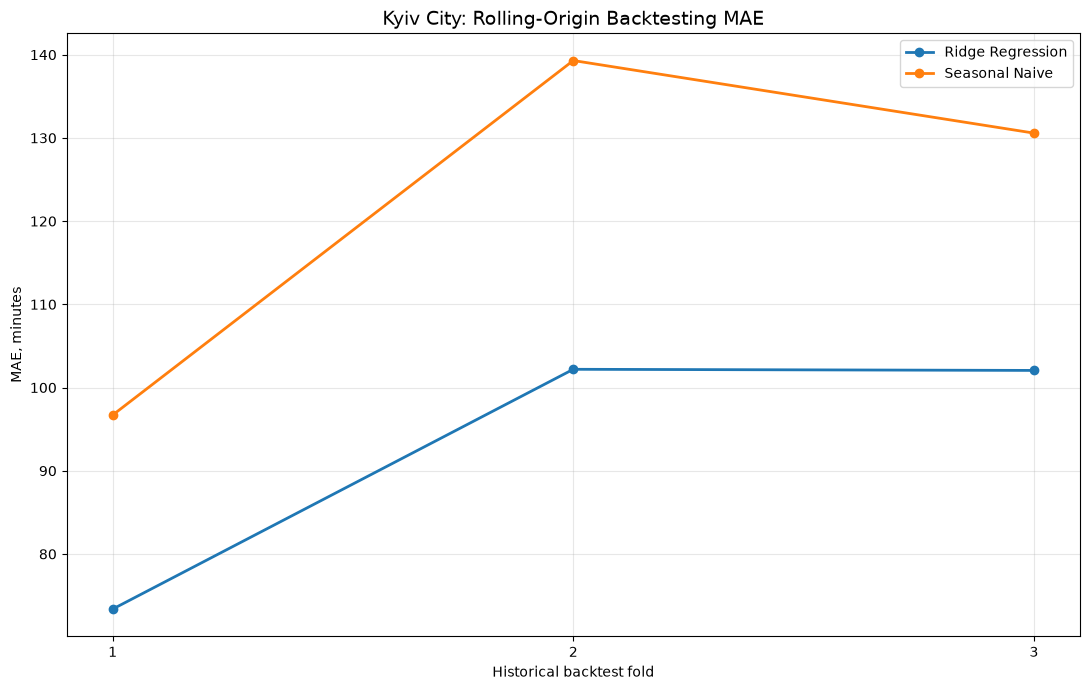

REUSABLE ROLLING-ORIGIN BACKTESTING
Final untouched test period: 2025-06-04 to 2025-11-30
Historical folds: 3
Test horizon per fold: 120 days

Backtest metrics by model and fold:


,fold_id,model_family,selected_alpha,train_start_date,train_end_date,test_start_date,test_end_date,mae_min,rmse_min,smape_percent
0,1,Ridge Regression,1000.0,2022-04-12,2024-06-08,2024-06-09,2024-10-06,73.380,114.304,97.744
1,1,Seasonal Naive,NaN,2022-04-12,2024-06-08,2024-06-09,2024-10-06,96.699,147.603,119.802
2,2,Ridge Regression,1000.0,2022-04-12,2024-10-06,2024-10-07,2025-02-03,102.195,140.073,90.921
3,2,Seasonal Naive,NaN,2022-04-12,2024-10-06,2024-10-07,2025-02-03,139.301,185.421,114.378
4,3,Ridge Regression,1000.0,2022-04-12,2025-02-03,2025-02-04,2025-06-03,102.060,140.964,85.362
5,3,Seasonal Naive,NaN,2022-04-12,2025-02-03,2025-02-04,2025-06-03,130.579,170.484,104.289



MAE comparison by fold:


,fold_id,train_start_date,train_end_date,train_rows,test_start_date,test_end_date,test_rows,Ridge Regression,Seasonal Naive,ridge_mae_improvement_min,ridge_mae_improvement_percent
0,1,2022-04-12,2024-06-08,789,2024-06-09,2024-10-06,120,73.380,96.699,23.319,24.115
1,2,2022-04-12,2024-10-06,909,2024-10-07,2025-02-03,120,102.195,139.301,37.105,26.637
2,3,2022-04-12,2025-02-03,1029,2025-02-04,2025-06-03,120,102.060,130.579,28.519,21.841



Average performance across folds:


,model_family,folds,mean_mae_min,median_mae_min,std_mae_min,mean_rmse_min,mean_smape_percent
0,Ridge Regression,3,92.545,102.060,16.597,131.780,91.343
1,Seasonal Naive,3,122.193,130.579,22.505,167.836,112.823



✅ Reusable rolling-origin backtesting completed successfully.
Metrics: D:\it10\PythonProject2\reports\rolling_origin_backtest_metrics.csv
Fold summary: D:\it10\PythonProject2\reports\rolling_origin_backtest_fold_summary.csv
Figure: D:\it10\PythonProject2\reports\figures\11_rolling_origin_backtest_mae.png


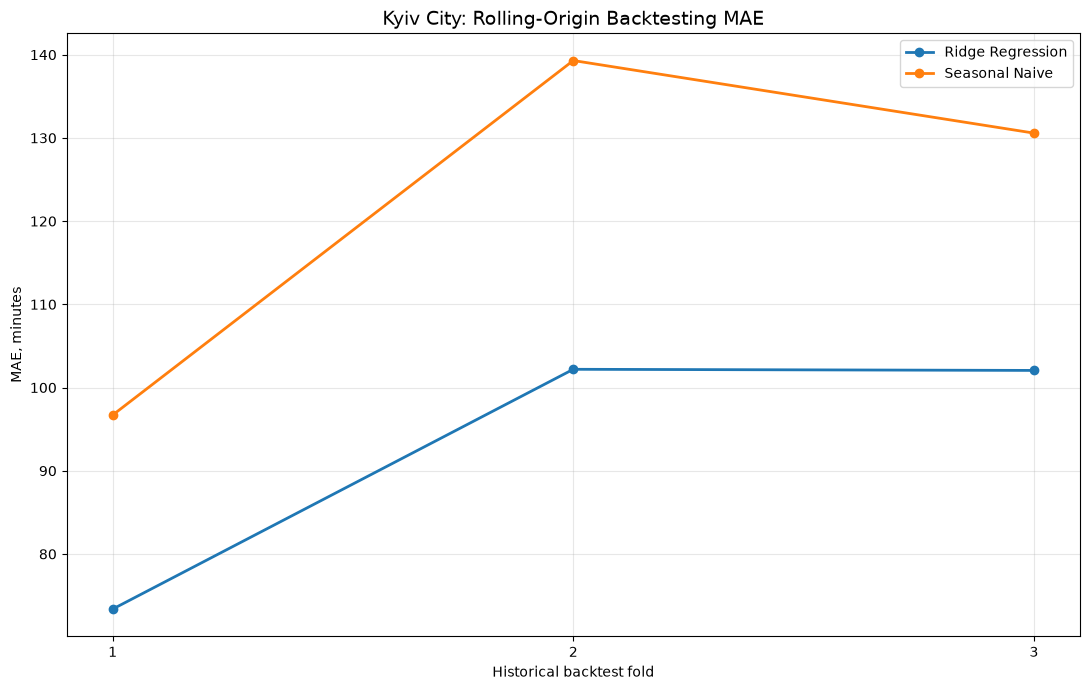

In [21]:
# =====================================================================
# Reusable rolling-origin backtesting:
# Ridge Regression vs Seasonal Naive
# =====================================================================

import importlib

import pandas as pd
from IPython.display import display

import config
import forecasting

importlib.reload(config)
importlib.reload(forecasting)

from forecasting import (
    plot_rolling_origin_backtest_mae,
    run_rolling_origin_backtest,
)


# ---------------------------------------------------------------------
# 1. Load configuration and prepared datasets
# ---------------------------------------------------------------------

FORECAST_FEATURES_FILE = config.FORECAST_FEATURES_FILE
FORECAST_TEST_FILE = config.FORECAST_TEST_FILE
FORECAST_REGION = config.FORECAST_REGION

FORECAST_LAGS = config.FORECAST_LAGS
FORECAST_ROLLING_WINDOWS = config.FORECAST_ROLLING_WINDOWS

RIDGE_ALPHA_CANDIDATES = config.RIDGE_ALPHA_CANDIDATES
RIDGE_TIME_SERIES_SPLITS = config.RIDGE_TIME_SERIES_SPLITS

ROLLING_ORIGIN_N_FOLDS = config.ROLLING_ORIGIN_N_FOLDS
ROLLING_ORIGIN_TEST_SIZE_DAYS = (
    config.ROLLING_ORIGIN_TEST_SIZE_DAYS
)

BACKTEST_METRICS_FILE = (
    config.ROLLING_ORIGIN_BACKTEST_METRICS_FILE
)

BACKTEST_FOLD_SUMMARY_FILE = (
    config.ROLLING_ORIGIN_BACKTEST_FOLD_SUMMARY_FILE
)

BACKTEST_FIGURE = config.ROLLING_ORIGIN_BACKTEST_FIGURE


# ---------------------------------------------------------------------
# 2. Load the feature dataset and locate the untouched final test period
# ---------------------------------------------------------------------

feature_data = pd.read_csv(
    FORECAST_FEATURES_FILE,
    parse_dates=["date"],
)

final_test_data = pd.read_csv(
    FORECAST_TEST_FILE,
    parse_dates=["date"],
)

final_test_start_date = final_test_data["date"].min()

if pd.isna(final_test_start_date):
    raise ValueError(
        "Could not determine the start of the final test period."
    )


# ---------------------------------------------------------------------
# 3. Rebuild the same 13 Ridge feature names
# ---------------------------------------------------------------------

feature_columns = [
    *[
        f"lag_{lag}"
        for lag in FORECAST_LAGS
    ],
    *[
        f"rolling_mean_{window}"
        for window in FORECAST_ROLLING_WINDOWS
    ],
    "day_of_week",
    "is_weekend",
    "month",
    "day_of_week_sin",
    "day_of_week_cos",
    "month_sin",
    "month_cos",
]


# ---------------------------------------------------------------------
# 4. Run reusable historical rolling-origin backtesting
# ---------------------------------------------------------------------

(
    backtest_metrics,
    fold_summary,
    model_summary,
) = run_rolling_origin_backtest(
    feature_data=feature_data,
    forecast_region=FORECAST_REGION,
    feature_columns=feature_columns,
    final_test_start_date=final_test_start_date,
    alpha_candidates=RIDGE_ALPHA_CANDIDATES,
    time_series_splits=RIDGE_TIME_SERIES_SPLITS,
    n_folds=ROLLING_ORIGIN_N_FOLDS,
    test_size_days=ROLLING_ORIGIN_TEST_SIZE_DAYS,
)


# ---------------------------------------------------------------------
# 5. Save reusable results
# ---------------------------------------------------------------------

BACKTEST_METRICS_FILE.parent.mkdir(
    parents=True,
    exist_ok=True,
)

BACKTEST_FOLD_SUMMARY_FILE.parent.mkdir(
    parents=True,
    exist_ok=True,
)

backtest_metrics.to_csv(
    BACKTEST_METRICS_FILE,
    index=False,
)

fold_summary.to_csv(
    BACKTEST_FOLD_SUMMARY_FILE,
    index=False,
)


# ---------------------------------------------------------------------
# 6. Create and save the MAE comparison chart
# ---------------------------------------------------------------------

figure, axes = plot_rolling_origin_backtest_mae(
    backtest_metrics=backtest_metrics,
    forecast_region=FORECAST_REGION,
    output_path=BACKTEST_FIGURE,
)

display(figure)


# ---------------------------------------------------------------------
# 7. Display final backtesting results
# ---------------------------------------------------------------------

print("=" * 78)
print("REUSABLE ROLLING-ORIGIN BACKTESTING")
print("=" * 78)

print(
    "Final untouched test period: "
    f"{final_test_data['date'].min().date()} "
    f"to {final_test_data['date'].max().date()}"
)

print(
    f"Historical folds: {ROLLING_ORIGIN_N_FOLDS}"
)

print(
    "Test horizon per fold: "
    f"{ROLLING_ORIGIN_TEST_SIZE_DAYS} days"
)

print("\nBacktest metrics by model and fold:")
display(
    backtest_metrics[
        [
            "fold_id",
            "model_family",
            "selected_alpha",
            "train_start_date",
            "train_end_date",
            "test_start_date",
            "test_end_date",
            "mae_min",
            "rmse_min",
            "smape_percent",
        ]
    ].round(3)
)

print("\nMAE comparison by fold:")
display(
    fold_summary.round(3)
)

print("\nAverage performance across folds:")
display(
    model_summary.round(3)
)


# ---------------------------------------------------------------------
# 8. Final validation
# ---------------------------------------------------------------------

assert len(backtest_metrics) == (
    ROLLING_ORIGIN_N_FOLDS * 2
)

assert len(fold_summary) == ROLLING_ORIGIN_N_FOLDS

assert pd.to_datetime(
    backtest_metrics["test_end_date"]
).max() < pd.to_datetime(
    final_test_start_date
)

assert BACKTEST_METRICS_FILE.exists()
assert BACKTEST_FOLD_SUMMARY_FILE.exists()
assert BACKTEST_FIGURE.exists()

print(
    "\n✅ Reusable rolling-origin backtesting completed successfully."
)

print(f"Metrics: {BACKTEST_METRICS_FILE}")
print(f"Fold summary: {BACKTEST_FOLD_SUMMARY_FILE}")
print(f"Figure: {BACKTEST_FIGURE}")

In [22]:
import importlib
import config

importlib.reload(config)

print(config.__file__)
print(config.FORECAST_FEATURES_FILE)
print(config.FORECAST_FEATURES_FILE.exists())

D:\it10\PythonProject2\src\config.py
D:\it10\PythonProject2\data\processed\kyiv_city_forecast_features.csv
True


In [23]:
import importlib
import config

importlib.reload(config)

print(config.__file__)
print("Lags:", config.FORECAST_LAGS)
print("Rolling windows:", config.FORECAST_ROLLING_WINDOWS)

D:\it10\PythonProject2\src\config.py
Lags: [1, 7, 14]
Rolling windows: [7, 14, 28]


In [24]:
import importlib
import config

importlib.reload(config)

print("Loaded config from:", config.__file__)
print("Lags:", config.FORECAST_LAGS)
print("Rolling windows:", config.FORECAST_ROLLING_WINDOWS)
print("Ridge alphas:", config.RIDGE_ALPHA_CANDIDATES)
print("TimeSeriesSplit folds:", config.RIDGE_TIME_SERIES_SPLITS)
print("Backtest folds:", config.ROLLING_ORIGIN_N_FOLDS)

Loaded config from: D:\it10\PythonProject2\src\config.py
Lags: [1, 7, 14]
Rolling windows: [7, 14, 28]
Ridge alphas: [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
TimeSeriesSplit folds: 5
Backtest folds: 3


## Interpretation of rolling-origin backtesting

Rolling-origin backtesting was performed using three historical test windows of 120 days each. For every fold, Ridge Regression was trained only on observations available before that fold, while the final 180-day test period from 2025-06-04 to 2025-11-30 remained untouched.

Ridge Regression outperformed the Seasonal Naive baseline in all three historical folds:

| Fold | Ridge MAE, min | Seasonal Naive MAE, min |  Ridge improvement |
| ---: | -------------: | ----------------------: | -----------------: |
|    1 |         73.380 |                  96.699 | 23.319 min (24.1%) |
|    2 |        102.195 |                 139.301 | 37.105 min (26.6%) |
|    3 |        102.060 |                 130.579 | 28.519 min (21.8%) |

Across all three folds, Ridge Regression achieved a mean MAE of 92.545 minutes, compared with 122.193 minutes for Seasonal Naive. This is an average MAE reduction of 29.648 minutes, or approximately 24.3%.

Ridge Regression also had a lower mean RMSE: 131.780 minutes compared with 167.836 minutes for Seasonal Naive. The mean sMAPE was lower for Ridge as well, but MAE is treated as the primary metric because the series contains zero-duration and low-duration days, for which percentage-based errors can be unstable.

The backtesting results indicate that the Ridge model's improvement is not limited to one final test period. Its advantage over the weekly Seasonal Naive baseline was repeated across several historical periods. However, the magnitude of the errors changes between folds, which is consistent with a non-stationary time series affected by changing external conditions.

These results describe retrospective predictive performance only. The model is not intended for real-time safety decisions or operational alert prediction.


In [25]:
# =====================================================================
# Classical time-series models:
# ARIMA / SARIMA data preparation and leakage checks
# =====================================================================

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# 1. Load the already prepared chronological train/test datasets
# ---------------------------------------------------------------------

CLASSICAL_TRAIN_FILE = config.FORECAST_TRAIN_FILE
CLASSICAL_TEST_FILE = config.FORECAST_TEST_FILE

CLASSICAL_TARGET_COLUMN = "target"

classical_train = pd.read_csv(
    CLASSICAL_TRAIN_FILE,
    parse_dates=["date"],
)

classical_test = pd.read_csv(
    CLASSICAL_TEST_FILE,
    parse_dates=["date"],
)

classical_train = classical_train.sort_values("date").reset_index(drop=True)
classical_test = classical_test.sort_values("date").reset_index(drop=True)


# ---------------------------------------------------------------------
# 2. Validate structure and chronological separation
# ---------------------------------------------------------------------

required_columns = {"date", CLASSICAL_TARGET_COLUMN}

for dataset_name, dataset in {
    "classical_train": classical_train,
    "classical_test": classical_test,
}.items():
    missing_columns = required_columns - set(dataset.columns)

    if missing_columns:
        raise KeyError(
            f"{dataset_name} is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    if dataset["date"].duplicated().any():
        raise ValueError(
            f"{dataset_name} contains duplicate dates."
        )

    if not dataset["date"].is_monotonic_increasing:
        raise ValueError(
            f"{dataset_name} dates are not sorted in ascending order."
        )

    if dataset[CLASSICAL_TARGET_COLUMN].isna().any():
        raise ValueError(
            f"{dataset_name} contains missing target values."
        )

    if (dataset[CLASSICAL_TARGET_COLUMN] < 0).any():
        raise ValueError(
            f"{dataset_name} contains negative target values."
        )


train_last_date = classical_train["date"].max()
test_first_date = classical_test["date"].min()

if train_last_date >= test_first_date:
    raise ValueError(
        "Train/test leakage risk: training dates overlap with "
        "or extend beyond the start of the test period."
    )


# ---------------------------------------------------------------------
# 3. Create univariate daily time series for classical models
# ---------------------------------------------------------------------

y_train_original = pd.Series(
    data=classical_train[CLASSICAL_TARGET_COLUMN].to_numpy(),
    index=classical_train["date"],
    name="total_duration_min",
)

y_test_original = pd.Series(
    data=classical_test[CLASSICAL_TARGET_COLUMN].to_numpy(),
    index=classical_test["date"],
    name="total_duration_min",
)

y_train_original = y_train_original.asfreq("D")
y_test_original = y_test_original.asfreq("D")

if y_train_original.isna().any():
    raise ValueError(
        "The classical training series has missing calendar days."
    )

if y_test_original.isna().any():
    raise ValueError(
        "The classical test series has missing calendar days."
    )


# ---------------------------------------------------------------------
# 4. Optional log1p transformation for ARIMA/SARIMA
# ---------------------------------------------------------------------

USE_LOG1P_TRANSFORM = config.USE_LOG1P_TRANSFORM

if USE_LOG1P_TRANSFORM:
    y_train_model = np.log1p(y_train_original)
    y_test_model = np.log1p(y_test_original)
else:
    y_train_model = y_train_original.copy()
    y_test_model = y_test_original.copy()


# ---------------------------------------------------------------------
# 5. Final checks and summary
# ---------------------------------------------------------------------

assert len(y_train_original) == len(classical_train)
assert len(y_test_original) == len(classical_test)

assert y_train_original.index.max() < y_test_original.index.min()

assert (y_train_original >= 0).all()
assert (y_test_original >= 0).all()

print("=" * 78)
print("CLASSICAL MODELS DATA PREPARATION COMPLETED")
print("=" * 78)

print(f"Target variable: {CLASSICAL_TARGET_COLUMN}")
print(f"Original target meaning: total daily alert duration in minutes")

print("\nTraining period:")
print(f"Start date: {y_train_original.index.min().date()}")
print(f"End date: {y_train_original.index.max().date()}")
print(f"Number of days: {len(y_train_original):,}")

print("\nFinal test period:")
print(f"Start date: {y_test_original.index.min().date()}")
print(f"End date: {y_test_original.index.max().date()}")
print(f"Number of days: {len(y_test_original):,}")

print("\nData checks:")
print("✓ Train and test periods do not overlap.")
print("✓ Dates are continuous daily observations.")
print("✓ No missing target values.")
print("✓ No negative target values.")

print("\nTransformation:")
if USE_LOG1P_TRANSFORM:
    print("✓ log1p(total_duration_min) will be used for ARIMA/SARIMA.")
    print("  Inverse transformation after forecasting: expm1(prediction).")
else:
    print("✓ ARIMA/SARIMA will use the original duration scale.")

print("\nOriginal-scale summary:")
print(
    f"Train mean: {y_train_original.mean():.2f} minutes; "
    f"train median: {y_train_original.median():.2f} minutes"
)
print(
    f"Test mean: {y_test_original.mean():.2f} minutes; "
    f"test median: {y_test_original.median():.2f} minutes"
)
print(
    f"Zero-duration days in train: {(y_train_original == 0).sum():,}"
)
print(
    f"Zero-duration days in test: {(y_test_original == 0).sum():,}"
)

CLASSICAL MODELS DATA PREPARATION COMPLETED
Target variable: target
Original target meaning: total daily alert duration in minutes

Training period:
Start date: 2022-04-12
End date: 2025-06-03
Number of days: 1,149

Final test period:
Start date: 2025-06-04
End date: 2025-11-30
Number of days: 180

Data checks:
✓ Train and test periods do not overlap.
✓ Dates are continuous daily observations.
✓ No missing target values.
✓ No negative target values.

Transformation:
✓ log1p(total_duration_min) will be used for ARIMA/SARIMA.
  Inverse transformation after forecasting: expm1(prediction).

Original-scale summary:
Train mean: 87.95 minutes; train median: 46.25 minutes
Test mean: 115.51 minutes; test median: 46.32 minutes
Zero-duration days in train: 372
Zero-duration days in test: 28


In [26]:
# =====================================================================
# Classical time-series models:
# use the full original daily series for ARIMA / SARIMA
# =====================================================================

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# 1. Configuration and final test boundary
# ---------------------------------------------------------------------

CLASSICAL_DAILY_FILE = config.DAILY_REGION_METRICS_FILE
CLASSICAL_TEST_FILE = config.FORECAST_TEST_FILE

CLASSICAL_REGION = config.FORECAST_REGION
CLASSICAL_TARGET_COLUMN = config.FORECAST_TARGET_COLUMN

USE_LOG1P_TRANSFORM = config.USE_LOG1P_TRANSFORM


# The existing Ridge / Seasonal Naive test file determines the final,
# untouched evaluation period for every model.
forecast_test_dates = pd.read_csv(
    CLASSICAL_TEST_FILE,
    usecols=["date"],
    parse_dates=["date"],
)["date"].sort_values().reset_index(drop=True)

if forecast_test_dates.empty:
    raise ValueError("Forecast test CSV does not contain any dates.")

if forecast_test_dates.duplicated().any():
    raise ValueError("Forecast test CSV contains duplicate dates.")

expected_test_dates = pd.date_range(
    start=forecast_test_dates.min(),
    end=forecast_test_dates.max(),
    freq="D",
)

if not pd.DatetimeIndex(forecast_test_dates).equals(expected_test_dates):
    raise ValueError(
        "Forecast test dates are not a continuous daily sequence."
    )

test_start_date = forecast_test_dates.min()
test_end_date = forecast_test_dates.max()


# ---------------------------------------------------------------------
# 2. Load the original daily Kyiv City series
# ---------------------------------------------------------------------

daily_metrics_classical = pd.read_csv(
    CLASSICAL_DAILY_FILE,
    parse_dates=["date"],
)

required_columns = {
    "date",
    "region",
    CLASSICAL_TARGET_COLUMN,
}

missing_columns = required_columns - set(daily_metrics_classical.columns)

if missing_columns:
    raise KeyError(
        "Daily metrics file is missing required columns: "
        f"{sorted(missing_columns)}"
    )

kyiv_classical_daily = (
    daily_metrics_classical.loc[
        daily_metrics_classical["region"].eq(CLASSICAL_REGION),
        ["date", CLASSICAL_TARGET_COLUMN],
    ]
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

if kyiv_classical_daily.empty:
    raise ValueError(
        f"No daily data were found for region: {CLASSICAL_REGION}"
    )

if kyiv_classical_daily["date"].duplicated().any():
    raise ValueError(
        "Duplicate dates were found in the original Kyiv City series."
    )

kyiv_classical_daily[CLASSICAL_TARGET_COLUMN] = pd.to_numeric(
    kyiv_classical_daily[CLASSICAL_TARGET_COLUMN],
    errors="coerce",
)

if kyiv_classical_daily[CLASSICAL_TARGET_COLUMN].isna().any():
    raise ValueError(
        "The original Kyiv City series contains invalid target values."
    )

if (kyiv_classical_daily[CLASSICAL_TARGET_COLUMN] < 0).any():
    raise ValueError(
        "The original Kyiv City series contains negative durations."
    )


# ---------------------------------------------------------------------
# 3. Create one continuous daily univariate series
# ---------------------------------------------------------------------

y_all_original = (
    kyiv_classical_daily
    .set_index("date")[CLASSICAL_TARGET_COLUMN]
    .asfreq("D")
    .rename("total_duration_min")
)

if y_all_original.isna().any():
    raise ValueError(
        "The original Kyiv City daily series is not continuous."
    )

if test_start_date not in y_all_original.index:
    raise ValueError(
        "The start of the final test period is missing "
        "from the original daily series."
    )

if test_end_date not in y_all_original.index:
    raise ValueError(
        "The end of the final test period is missing "
        "from the original daily series."
    )


# ---------------------------------------------------------------------
# 4. Split by the already fixed final test boundary
# ---------------------------------------------------------------------

y_train_original = y_all_original.loc[
    y_all_original.index < test_start_date
].copy()

y_test_original = y_all_original.loc[
    (y_all_original.index >= test_start_date)
    & (y_all_original.index <= test_end_date)
].copy()

if y_train_original.empty:
    raise ValueError("Classical-model training series is empty.")

if y_test_original.empty:
    raise ValueError("Classical-model test series is empty.")

if y_train_original.index.max() >= y_test_original.index.min():
    raise ValueError(
        "Train/test leakage risk: periods overlap."
    )

if not y_test_original.index.equals(
    pd.DatetimeIndex(forecast_test_dates)
):
    raise ValueError(
        "The ARIMA/SARIMA test dates do not exactly match "
        "the existing forecasting test dates."
    )


# ---------------------------------------------------------------------
# 5. Logarithmic transformation for model fitting
# ---------------------------------------------------------------------

if USE_LOG1P_TRANSFORM:
    y_train_model = np.log1p(y_train_original)
    y_test_model = np.log1p(y_test_original)
else:
    y_train_model = y_train_original.copy()
    y_test_model = y_test_original.copy()


# ---------------------------------------------------------------------
# 6. Final checks and summary
# ---------------------------------------------------------------------

assert y_train_original.index.is_monotonic_increasing
assert y_test_original.index.is_monotonic_increasing

assert not y_train_original.isna().any()
assert not y_test_original.isna().any()

assert (y_train_original >= 0).all()
assert (y_test_original >= 0).all()

print("=" * 78)
print("CLASSICAL SERIES PREPARATION COMPLETED")
print("=" * 78)

print(f"Region: {CLASSICAL_REGION}")
print(f"Original target: {CLASSICAL_TARGET_COLUMN}")

print("\nFull original daily series:")
print(
    f"{y_all_original.index.min().date()} "
    f"to {y_all_original.index.max().date()}"
)
print(f"Number of daily observations: {len(y_all_original):,}")

print("\nARIMA/SARIMA training period:")
print(
    f"{y_train_original.index.min().date()} "
    f"to {y_train_original.index.max().date()}"
)
print(f"Training days: {len(y_train_original):,}")

print("\nShared final test period:")
print(
    f"{y_test_original.index.min().date()} "
    f"to {y_test_original.index.max().date()}"
)
print(f"Test days: {len(y_test_original):,}")

print("\nValidation checks:")
print("✓ ARIMA/SARIMA use the original continuous daily series.")
print("✓ The final test period exactly matches Ridge and Seasonal Naive.")
print("✓ No future observations are included in the training series.")
print("✓ No missing or negative durations were found.")

print("\nTransformation:")
if USE_LOG1P_TRANSFORM:
    print("✓ ARIMA/SARIMA fitting scale: log1p(total_duration_min)")
    print("✓ Back transformation: expm1(prediction)")
else:
    print("✓ ARIMA/SARIMA fitting scale: original minutes")

print("\nImportant note:")
print(
    "ARIMA/SARIMA use 28 additional early historical days compared "
    "with Ridge because they do not require lag or rolling features."
)

CLASSICAL SERIES PREPARATION COMPLETED
Region: Kyiv City
Original target: total_duration_min

Full original daily series:
2022-03-15 to 2025-11-30
Number of daily observations: 1,357

ARIMA/SARIMA training period:
2022-03-15 to 2025-06-03
Training days: 1,177

Shared final test period:
2025-06-04 to 2025-11-30
Test days: 180

Validation checks:
✓ ARIMA/SARIMA use the original continuous daily series.
✓ The final test period exactly matches Ridge and Seasonal Naive.
✓ No future observations are included in the training series.
✓ No missing or negative durations were found.

Transformation:
✓ ARIMA/SARIMA fitting scale: log1p(total_duration_min)
✓ Back transformation: expm1(prediction)

Important note:
ARIMA/SARIMA use 28 additional early historical days compared with Ridge because they do not require lag or rolling features.


In [27]:
# =====================================================================
# Classical time-series models:
# train-only ARIMA order selection with expanding validation
# =====================================================================

import warnings

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tools.sm_exceptions import ConvergenceWarning



# ---------------------------------------------------------------------
# 1. Settings and safety checks
# ---------------------------------------------------------------------

ARIMA_ORDER_CANDIDATES = config.ARIMA_ORDER_CANDIDATES

VALIDATION_FOLDS = config.CLASSICAL_MODEL_VALIDATION_FOLDS
VALIDATION_SIZE_DAYS = config.CLASSICAL_MODEL_VALIDATION_SIZE_DAYS

VALIDATION_RESULTS_FILE = config.ARIMA_SARIMA_VALIDATION_METRICS_FILE


if len(ARIMA_ORDER_CANDIDATES) == 0:
    raise ValueError("ARIMA_ORDER_CANDIDATES is empty.")

if VALIDATION_FOLDS < 1:
    raise ValueError("CLASSICAL_MODEL_VALIDATION_FOLDS must be at least 1.")

if VALIDATION_SIZE_DAYS < 1:
    raise ValueError(
        "CLASSICAL_MODEL_VALIDATION_SIZE_DAYS must be at least 1."
    )

total_validation_days = VALIDATION_FOLDS * VALIDATION_SIZE_DAYS

if len(y_train_model) <= total_validation_days:
    raise ValueError(
        "The training series is too short for the requested "
        "number of validation folds and validation size."
    )

if not y_train_model.index.equals(y_train_original.index):
    raise ValueError(
        "Model-scale and original-scale training series "
        "have different dates."
    )

if y_train_original.index.max() >= y_test_original.index.min():
    raise ValueError(
        "Leakage risk: the training period overlaps with final test."
    )


# ---------------------------------------------------------------------
# 2. Create expanding validation folds inside TRAIN only
# ---------------------------------------------------------------------

validation_folds = []

first_validation_start_position = (
    len(y_train_model) - total_validation_days
)

for fold_number in range(1, VALIDATION_FOLDS + 1):
    validation_start_position = (
        first_validation_start_position
        + (fold_number - 1) * VALIDATION_SIZE_DAYS
    )

    validation_end_position = (
        validation_start_position
        + VALIDATION_SIZE_DAYS
    )

    training_series_for_fold = y_train_model.iloc[
        :validation_start_position
    ]

    validation_series_for_fold_model = y_train_model.iloc[
        validation_start_position:validation_end_position
    ]

    validation_series_for_fold_original = y_train_original.iloc[
        validation_start_position:validation_end_position
    ]

    if training_series_for_fold.empty:
        raise ValueError(
            f"Fold {fold_number} has an empty training series."
        )

    if len(validation_series_for_fold_model) != VALIDATION_SIZE_DAYS:
        raise ValueError(
            f"Fold {fold_number} has an unexpected validation length."
        )

    if training_series_for_fold.index.max() >= (
        validation_series_for_fold_model.index.min()
    ):
        raise ValueError(
            f"Fold {fold_number} has overlapping train/validation dates."
        )

    validation_folds.append(
        {
            "fold": fold_number,
            "train_model": training_series_for_fold,
            "validation_model": validation_series_for_fold_model,
            "validation_original": validation_series_for_fold_original,
        }
    )


print("=" * 78)
print("ARIMA TRAIN-ONLY EXPANDING VALIDATION")
print("=" * 78)

for fold_info in validation_folds:
    print(f"\nFold {fold_info['fold']}:")
    print(
        "  Training: "
        f"{fold_info['train_model'].index.min().date()} "
        f"to {fold_info['train_model'].index.max().date()} "
        f"({len(fold_info['train_model']):,} days)"
    )
    print(
        "  Validation: "
        f"{fold_info['validation_model'].index.min().date()} "
        f"to {fold_info['validation_model'].index.max().date()} "
        f"({len(fold_info['validation_model']):,} days)"
    )

print("\nFinal untouched test period:")
print(
    f"  {y_test_original.index.min().date()} "
    f"to {y_test_original.index.max().date()} "
    f"({len(y_test_original):,} days)"
)


# ---------------------------------------------------------------------
# 3. Helper functions
# ---------------------------------------------------------------------

def inverse_target_transform(values, use_log1p=True):
    """
    Return predictions to the original minutes scale
    and prevent physically impossible negative durations.
    """
    values = np.asarray(values, dtype=float)

    if use_log1p:
        values = np.expm1(values)

    return np.clip(values, a_min=0.0, a_max=None)


def rolling_one_step_arima_predictions(
    training_series,
    validation_series,
    order,
):
    """
    Fit ARIMA once on the fold training history.

    Then produce a one-day-ahead forecast for every validation day.
    After each prediction, append the actual newly observed value
    without refitting model parameters.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        warnings.simplefilter("ignore", UserWarning)
        warnings.simplefilter("ignore", RuntimeWarning)

        fitted_model = ARIMA(
            training_series,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit()

    current_model = fitted_model
    one_step_predictions = []

    for date, actual_value in validation_series.items():
        one_step_forecast = current_model.get_forecast(steps=1)

        predicted_value = float(
            np.asarray(one_step_forecast.predicted_mean)[0]
        )

        one_step_predictions.append(predicted_value)

        observed_value = pd.Series(
            data=[float(actual_value)],
            index=pd.date_range(
                start=date,
                periods=1,
                freq="D",
            ),
            name=validation_series.name,
        )

        current_model = current_model.append(
            observed_value,
            refit=False,
        )

    return np.asarray(one_step_predictions, dtype=float)


# ---------------------------------------------------------------------
# 4. Evaluate each ARIMA candidate on train-only folds
# ---------------------------------------------------------------------

arima_validation_records = []

total_candidates = len(ARIMA_ORDER_CANDIDATES)

for candidate_number, order in enumerate(
    ARIMA_ORDER_CANDIDATES,
    start=1,
):
    print(
        f"\nEvaluating ARIMA candidate "
        f"{candidate_number}/{total_candidates}: ARIMA{order}"
    )

    fold_mae_values = []
    candidate_errors = []

    for fold_info in validation_folds:
        fold_number = fold_info["fold"]

        try:
            validation_predictions_model_scale = (
                rolling_one_step_arima_predictions(
                    training_series=fold_info["train_model"],
                    validation_series=fold_info["validation_model"],
                    order=order,
                )
            )

            validation_predictions_original_scale = (
                inverse_target_transform(
                    validation_predictions_model_scale,
                    use_log1p=USE_LOG1P_TRANSFORM,
                )
            )

            fold_mae = mean_absolute_error(
                fold_info["validation_original"].to_numpy(),
                validation_predictions_original_scale,
            )

            fold_mae_values.append(float(fold_mae))

        except Exception as error:
            candidate_errors.append(
                f"Fold {fold_number}: {type(error).__name__}: {error}"
            )

    successful_folds = len(fold_mae_values)

    record = {
        "model_family": "ARIMA",
        "order": str(order),
        "seasonal_order": "",
        "successful_folds": successful_folds,
        "required_folds": VALIDATION_FOLDS,
        "fit_success": successful_folds == VALIDATION_FOLDS,
        "mean_validation_mae_min": (
            float(np.mean(fold_mae_values))
            if fold_mae_values
            else np.nan
        ),
        "validation_mae_std_min": (
            float(np.std(fold_mae_values, ddof=1))
            if len(fold_mae_values) > 1
            else np.nan
        ),
        "errors": " | ".join(candidate_errors),
    }

    for fold_number in range(1, VALIDATION_FOLDS + 1):
        column_name = f"fold_{fold_number}_mae_min"

        if fold_number <= len(fold_mae_values):
            record[column_name] = fold_mae_values[fold_number - 1]
        else:
            record[column_name] = np.nan

    arima_validation_records.append(record)


# ---------------------------------------------------------------------
# 5. Create, save and display the ARIMA validation summary
# ---------------------------------------------------------------------

arima_validation_metrics = pd.DataFrame(
    arima_validation_records
)

arima_validation_metrics = arima_validation_metrics.sort_values(
    by=[
        "fit_success",
        "mean_validation_mae_min",
    ],
    ascending=[
        False,
        True,
    ],
    na_position="last",
).reset_index(drop=True)

successful_arima_models = arima_validation_metrics.loc[
    arima_validation_metrics["fit_success"]
].copy()

if successful_arima_models.empty:
    raise RuntimeError(
        "None of the ARIMA candidate orders completed all "
        "train-only validation folds."
    )

best_arima_row = successful_arima_models.iloc[0]

best_arima_order = tuple(
    int(value)
    for value in (
        best_arima_row["order"]
        .replace("(", "")
        .replace(")", "")
        .split(",")
    )
)

VALIDATION_RESULTS_FILE.parent.mkdir(
    parents=True,
    exist_ok=True,
)

arima_validation_metrics.to_csv(
    VALIDATION_RESULTS_FILE,
    index=False,
)


# ---------------------------------------------------------------------
# 6. Final checks and output
# ---------------------------------------------------------------------

assert (
    arima_validation_metrics["model_family"]
    .eq("ARIMA")
    .all()
)

assert (
    arima_validation_metrics["required_folds"]
    .eq(VALIDATION_FOLDS)
    .all()
)

assert (
    arima_validation_metrics["successful_folds"]
    <= VALIDATION_FOLDS
).all()

assert y_train_original.index.max() < y_test_original.index.min()
assert VALIDATION_RESULTS_FILE.exists()

print("\n" + "=" * 78)
print("ARIMA ORDER SELECTION COMPLETED")
print("=" * 78)

print(f"Candidate orders evaluated: {len(ARIMA_ORDER_CANDIDATES)}")
print(f"Validation folds: {VALIDATION_FOLDS}")
print(f"Validation size per fold: {VALIDATION_SIZE_DAYS} days")
print(
    "Final test used for model selection: "
    "No — the final test remains untouched."
)

print("\nBest ARIMA order:")
print(f"ARIMA{best_arima_order}")

print("\nBest train-only validation result:")
print(
    f"Mean MAE: "
    f"{best_arima_row['mean_validation_mae_min']:.3f} minutes"
)

print(
    f"Validation MAE standard deviation: "
    f"{best_arima_row['validation_mae_std_min']:.3f} minutes"
)

print("\nTop candidate models:")
display(
    arima_validation_metrics[
        [
            "order",
            "successful_folds",
            "mean_validation_mae_min",
            "validation_mae_std_min",
            "fit_success",
        ]
    ].head(8)
)

print("\nSaved validation metrics:")
print(VALIDATION_RESULTS_FILE)

ARIMA TRAIN-ONLY EXPANDING VALIDATION

Fold 1:
  Training: 2022-03-15 to 2024-06-08 (817 days)
  Validation: 2024-06-09 to 2024-10-06 (120 days)

Fold 2:
  Training: 2022-03-15 to 2024-10-06 (937 days)
  Validation: 2024-10-07 to 2025-02-03 (120 days)

Fold 3:
  Training: 2022-03-15 to 2025-02-03 (1,057 days)
  Validation: 2025-02-04 to 2025-06-03 (120 days)

Final untouched test period:
  2025-06-04 to 2025-11-30 (180 days)

Evaluating ARIMA candidate 1/8: ARIMA(0, 0, 0)

Evaluating ARIMA candidate 2/8: ARIMA(1, 0, 0)

Evaluating ARIMA candidate 3/8: ARIMA(0, 0, 1)

Evaluating ARIMA candidate 4/8: ARIMA(1, 0, 1)

Evaluating ARIMA candidate 5/8: ARIMA(2, 0, 0)

Evaluating ARIMA candidate 6/8: ARIMA(0, 1, 1)

Evaluating ARIMA candidate 7/8: ARIMA(1, 1, 0)

Evaluating ARIMA candidate 8/8: ARIMA(1, 1, 1)

ARIMA ORDER SELECTION COMPLETED
Candidate orders evaluated: 8
Validation folds: 3
Validation size per fold: 120 days
Final test used for model selection: No — the final test remains unto

,order,successful_folds,mean_validation_mae_min,validation_mae_std_min,fit_success
0,"(0, 1, 1)",3,99.045116,22.685690,True
1,"(1, 1, 1)",3,99.063942,22.515998,True
2,"(1, 0, 1)",3,104.953182,26.840597,True
3,"(1, 1, 0)",3,105.620247,22.596429,True
4,"(2, 0, 0)",3,110.258872,30.823112,True
5,"(1, 0, 0)",3,111.827471,31.577339,True
6,"(0, 0, 1)",3,113.060296,32.318951,True
7,"(0, 0, 0)",3,115.188031,33.887692,True



Saved validation metrics:
D:\it10\PythonProject2\reports\arima_sarima_validation_metrics.csv


In [28]:
# =====================================================================
# Classical time-series models:
# train-only SARIMA order selection with expanding validation
# =====================================================================

import warnings

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning


# ---------------------------------------------------------------------
# 1. Settings and checks
# ---------------------------------------------------------------------

SARIMA_ORDER_CANDIDATES = config.SARIMA_ORDER_CANDIDATES

VALIDATION_FOLDS = config.CLASSICAL_MODEL_VALIDATION_FOLDS
VALIDATION_SIZE_DAYS = config.CLASSICAL_MODEL_VALIDATION_SIZE_DAYS

VALIDATION_RESULTS_FILE = config.ARIMA_SARIMA_VALIDATION_METRICS_FILE


if len(SARIMA_ORDER_CANDIDATES) == 0:
    raise ValueError("SARIMA_ORDER_CANDIDATES is empty.")

if "validation_folds" not in globals():
    raise RuntimeError(
        "validation_folds is missing. "
        "Run the ARIMA validation cell first."
    )

if "inverse_target_transform" not in globals():
    raise RuntimeError(
        "inverse_target_transform is missing. "
        "Run the ARIMA validation cell first."
    )

if len(validation_folds) != VALIDATION_FOLDS:
    raise ValueError(
        "The number of prepared validation folds does not match config."
    )

if y_train_original.index.max() >= y_test_original.index.min():
    raise ValueError(
        "Leakage risk: training period overlaps with final test period."
    )


# ---------------------------------------------------------------------
# 2. Helper function:
# one-step-ahead SARIMA predictions inside one validation fold
# ---------------------------------------------------------------------

def rolling_one_step_sarima_predictions(
    training_series,
    validation_series,
    order,
    seasonal_order,
):
    """
    Fit SARIMA once on the fold training data.

    Then make a one-day-ahead prediction for each validation date.
    After the actual observation becomes known, update the model state
    without refitting parameters.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        warnings.simplefilter("ignore", UserWarning)
        warnings.simplefilter("ignore", RuntimeWarning)

        fitted_model = SARIMAX(
            training_series,
            order=order,
            seasonal_order=seasonal_order,
            trend="n",
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)

    current_model = fitted_model
    one_step_predictions = []

    for date, actual_value in validation_series.items():
        one_step_forecast = current_model.get_forecast(steps=1)

        predicted_value = float(
            np.asarray(one_step_forecast.predicted_mean)[0]
        )

        one_step_predictions.append(predicted_value)

        observed_value = pd.Series(
            data=[float(actual_value)],
            index=pd.date_range(
                start=date,
                periods=1,
                freq="D",
            ),
            name=validation_series.name,
        )

        try:
            current_model = current_model.extend(observed_value)

        except Exception:
            current_model = current_model.append(
                observed_value,
                refit=False,
            )

    return np.asarray(one_step_predictions, dtype=float)


# ---------------------------------------------------------------------
# 3. Evaluate SARIMA candidates on train-only validation folds
# ---------------------------------------------------------------------

sarima_validation_records = []

total_candidates = len(SARIMA_ORDER_CANDIDATES)

print("=" * 78)
print("SARIMA TRAIN-ONLY EXPANDING VALIDATION")
print("=" * 78)

print(f"Candidate models: {total_candidates}")
print(f"Validation folds: {VALIDATION_FOLDS}")
print(f"Validation size per fold: {VALIDATION_SIZE_DAYS} days")
print("Seasonal period: 7 days")
print(
    "Final test used for model selection: "
    "No — final test remains untouched."
)

for candidate_number, (order, seasonal_order) in enumerate(
    SARIMA_ORDER_CANDIDATES,
    start=1,
):
    print(
        f"\nEvaluating SARIMA candidate "
        f"{candidate_number}/{total_candidates}: "
        f"SARIMA{order} x {seasonal_order}"
    )

    fold_mae_values = []
    candidate_errors = []

    for fold_info in validation_folds:
        fold_number = fold_info["fold"]

        try:
            validation_predictions_model_scale = (
                rolling_one_step_sarima_predictions(
                    training_series=fold_info["train_model"],
                    validation_series=fold_info["validation_model"],
                    order=order,
                    seasonal_order=seasonal_order,
                )
            )

            validation_predictions_original_scale = (
                inverse_target_transform(
                    validation_predictions_model_scale,
                    use_log1p=USE_LOG1P_TRANSFORM,
                )
            )

            fold_mae = mean_absolute_error(
                fold_info["validation_original"].to_numpy(),
                validation_predictions_original_scale,
            )

            fold_mae_values.append(float(fold_mae))

        except Exception as error:
            candidate_errors.append(
                f"Fold {fold_number}: "
                f"{type(error).__name__}: {error}"
            )

    successful_folds = len(fold_mae_values)

    record = {
        "model_family": "SARIMA",
        "order": str(order),
        "seasonal_order": str(seasonal_order),
        "successful_folds": successful_folds,
        "required_folds": VALIDATION_FOLDS,
        "fit_success": successful_folds == VALIDATION_FOLDS,
        "mean_validation_mae_min": (
            float(np.mean(fold_mae_values))
            if fold_mae_values
            else np.nan
        ),
        "validation_mae_std_min": (
            float(np.std(fold_mae_values, ddof=1))
            if len(fold_mae_values) > 1
            else np.nan
        ),
        "errors": " | ".join(candidate_errors),
    }

    for fold_number in range(1, VALIDATION_FOLDS + 1):
        column_name = f"fold_{fold_number}_mae_min"

        if fold_number <= len(fold_mae_values):
            record[column_name] = fold_mae_values[fold_number - 1]
        else:
            record[column_name] = np.nan

    sarima_validation_records.append(record)


# ---------------------------------------------------------------------
# 4. Create SARIMA validation table
# ---------------------------------------------------------------------

sarima_validation_metrics = pd.DataFrame(
    sarima_validation_records
)

sarima_validation_metrics = sarima_validation_metrics.sort_values(
    by=[
        "fit_success",
        "mean_validation_mae_min",
    ],
    ascending=[
        False,
        True,
    ],
    na_position="last",
).reset_index(drop=True)

successful_sarima_models = sarima_validation_metrics.loc[
    sarima_validation_metrics["fit_success"]
].copy()

if successful_sarima_models.empty:
    raise RuntimeError(
        "None of the SARIMA candidate models completed "
        "all train-only validation folds."
    )

best_sarima_row = successful_sarima_models.iloc[0]


# ---------------------------------------------------------------------
# 5. Combine ARIMA and SARIMA validation metrics in one CSV
# ---------------------------------------------------------------------

if VALIDATION_RESULTS_FILE.exists():
    existing_validation_metrics = pd.read_csv(
        VALIDATION_RESULTS_FILE
    )

    existing_validation_metrics = existing_validation_metrics.loc[
        existing_validation_metrics["model_family"].ne("SARIMA")
    ].copy()

    validation_metrics_all = pd.concat(
        [
            existing_validation_metrics,
            sarima_validation_metrics,
        ],
        ignore_index=True,
    )

else:
    validation_metrics_all = sarima_validation_metrics.copy()

validation_metrics_all = validation_metrics_all.sort_values(
    by=[
        "model_family",
        "fit_success",
        "mean_validation_mae_min",
    ],
    ascending=[
        True,
        False,
        True,
    ],
    na_position="last",
).reset_index(drop=True)

VALIDATION_RESULTS_FILE.parent.mkdir(
    parents=True,
    exist_ok=True,
)

validation_metrics_all.to_csv(
    VALIDATION_RESULTS_FILE,
    index=False,
)


# ---------------------------------------------------------------------
# 6. Final checks and output
# ---------------------------------------------------------------------

assert (
    sarima_validation_metrics["model_family"]
    .eq("SARIMA")
    .all()
)

assert (
    sarima_validation_metrics["successful_folds"]
    <= VALIDATION_FOLDS
).all()

assert VALIDATION_RESULTS_FILE.exists()

print("\n" + "=" * 78)
print("SARIMA ORDER SELECTION COMPLETED")
print("=" * 78)

print("\nBest SARIMA model:")
print(
    f"SARIMA{best_sarima_row['order']} "
    f"x {best_sarima_row['seasonal_order']}"
)

print("\nBest train-only validation result:")
print(
    f"Mean MAE: "
    f"{best_sarima_row['mean_validation_mae_min']:.3f} minutes"
)

print(
    f"Validation MAE standard deviation: "
    f"{best_sarima_row['validation_mae_std_min']:.3f} minutes"
)

print("\nTop SARIMA candidates:")
display(
    sarima_validation_metrics[
        [
            "order",
            "seasonal_order",
            "successful_folds",
            "mean_validation_mae_min",
            "validation_mae_std_min",
            "fit_success",
        ]
    ].head(10)
)

print("\nCombined ARIMA + SARIMA validation metrics saved to:")
print(VALIDATION_RESULTS_FILE)

SARIMA TRAIN-ONLY EXPANDING VALIDATION
Candidate models: 6
Validation folds: 3
Validation size per fold: 120 days
Seasonal period: 7 days
Final test used for model selection: No — final test remains untouched.

Evaluating SARIMA candidate 1/6: SARIMA(0, 0, 0) x (0, 1, 1, 7)

Evaluating SARIMA candidate 2/6: SARIMA(1, 0, 0) x (0, 1, 1, 7)

Evaluating SARIMA candidate 3/6: SARIMA(0, 0, 1) x (0, 1, 1, 7)

Evaluating SARIMA candidate 4/6: SARIMA(1, 0, 1) x (0, 1, 1, 7)

Evaluating SARIMA candidate 5/6: SARIMA(1, 1, 0) x (0, 1, 1, 7)

Evaluating SARIMA candidate 6/6: SARIMA(1, 1, 1) x (0, 1, 1, 7)

SARIMA ORDER SELECTION COMPLETED

Best SARIMA model:
SARIMA(1, 1, 1) x (0, 1, 1, 7)

Best train-only validation result:
Mean MAE: 99.757 minutes
Validation MAE standard deviation: 22.814 minutes

Top SARIMA candidates:


,order,seasonal_order,successful_folds,mean_validation_mae_min,validation_mae_std_min,fit_success
0,"(1, 1, 1)","(0, 1, 1, 7)",3,99.757082,22.814086,True
1,"(1, 0, 1)","(0, 1, 1, 7)",3,104.891847,26.810138,True
2,"(1, 0, 0)","(0, 1, 1, 7)",3,105.273933,26.123178,True
3,"(0, 0, 1)","(0, 1, 1, 7)",3,105.465092,26.236868,True
4,"(0, 0, 0)","(0, 1, 1, 7)",3,106.138953,27.207301,True
5,"(1, 1, 0)","(0, 1, 1, 7)",3,110.521091,20.957274,True



Combined ARIMA + SARIMA validation metrics saved to:
D:\it10\PythonProject2\reports\arima_sarima_validation_metrics.csv


In [29]:
# =====================================================================
# Classical time-series models:
# final ARIMA and SARIMA walk-forward forecasts on the untouched test set
# =====================================================================

import ast
import warnings

import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning


# ---------------------------------------------------------------------
# 1. Check that model selection has already been completed
# ---------------------------------------------------------------------

required_variables = [
    "y_train_model",
    "y_test_model",
    "y_train_original",
    "y_test_original",
    "best_arima_order",
    "best_sarima_row",
]

missing_variables = [
    variable_name
    for variable_name in required_variables
    if variable_name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Required variables are missing. Run the classical-series, "
        "ARIMA-selection and SARIMA-selection cells first.\n"
        f"Missing variables: {missing_variables}"
    )


# ---------------------------------------------------------------------
# 2. Load paths and fixed final test data
# ---------------------------------------------------------------------

FORECAST_TEST_FILE = config.FORECAST_TEST_FILE
FORECAST_METRICS_FILE = config.FORECAST_METRICS_FILE
CLASSICAL_PREDICTIONS_FILE = (
    config.ARIMA_SARIMA_TEST_PREDICTIONS_FILE
)

FORECAST_REGION = config.FORECAST_REGION
USE_LOG1P_TRANSFORM = config.USE_LOG1P_TRANSFORM

test_feature_data = pd.read_csv(
    FORECAST_TEST_FILE,
    parse_dates=["date"],
)

required_test_columns = {
    "date",
    "target",
    "seasonal_naive_prediction",
}

missing_test_columns = (
    required_test_columns - set(test_feature_data.columns)
)

if missing_test_columns:
    raise KeyError(
        "The stored test dataset is missing required columns:\n"
        f"{sorted(missing_test_columns)}"
    )

test_feature_data = (
    test_feature_data
    .sort_values("date")
    .reset_index(drop=True)
)

if test_feature_data["date"].duplicated().any():
    raise ValueError(
        "The stored test dataset contains duplicate dates."
    )

if not test_feature_data["date"].equals(
    pd.Series(y_test_original.index)
):
    raise ValueError(
        "The classical-model test dates do not match the stored "
        "Seasonal Naive / Ridge test dates."
    )

if not np.allclose(
    test_feature_data["target"].to_numpy(),
    y_test_original.to_numpy(),
):
    raise ValueError(
        "Actual test targets differ between the original daily series "
        "and the stored forecasting test dataset."
    )


# ---------------------------------------------------------------------
# 3. Parse the selected ARIMA and SARIMA orders
# ---------------------------------------------------------------------

def parse_order_tuple(order_value, expected_length, name):
    """
    Convert a stored order tuple or a tuple-like string into a tuple
    of integers with an expected number of components.
    """
    if isinstance(order_value, str):
        parsed_value = ast.literal_eval(order_value)
    else:
        parsed_value = tuple(order_value)

    parsed_value = tuple(
        int(component)
        for component in parsed_value
    )

    if len(parsed_value) != expected_length:
        raise ValueError(
            f"{name} must contain {expected_length} components. "
            f"Received: {parsed_value}"
        )

    return parsed_value


final_arima_order = parse_order_tuple(
    best_arima_order,
    expected_length=3,
    name="ARIMA order",
)

final_sarima_order = parse_order_tuple(
    best_sarima_row["order"],
    expected_length=3,
    name="SARIMA non-seasonal order",
)

final_sarima_seasonal_order = parse_order_tuple(
    best_sarima_row["seasonal_order"],
    expected_length=4,
    name="SARIMA seasonal order",
)


# ---------------------------------------------------------------------
# 4. Transformation helpers
# ---------------------------------------------------------------------

def inverse_model_scale(values, use_log1p=True):
    """
    Convert model-scale values back to minutes.

    Returns:
        raw_values:
            Back-transformed values before physical clipping.

        clipped_values:
            Values clipped at zero because negative alert duration
            is physically impossible.
    """
    raw_values = np.asarray(
        values,
        dtype=float,
    )

    if use_log1p:
        raw_values = np.expm1(raw_values)

    clipped_values = np.clip(
        raw_values,
        a_min=0.0,
        a_max=None,
    )

    return raw_values, clipped_values


def calculate_smape(actual_values, predicted_values):
    """
    Symmetric mean absolute percentage error in percent.

    If both actual and predicted values are zero,
    the contribution of that day is defined as zero.
    """
    actual_values = np.asarray(
        actual_values,
        dtype=float,
    )

    predicted_values = np.asarray(
        predicted_values,
        dtype=float,
    )

    denominator = (
        np.abs(actual_values)
        + np.abs(predicted_values)
    )

    smape_components = np.zeros_like(
        denominator,
        dtype=float,
    )

    nonzero_denominator_mask = denominator != 0

    smape_components[nonzero_denominator_mask] = (
        2.0
        * np.abs(
            actual_values[nonzero_denominator_mask]
            - predicted_values[nonzero_denominator_mask]
        )
        / denominator[nonzero_denominator_mask]
    )

    return float(
        np.mean(smape_components) * 100
    )


def calculate_metrics(actual_values, predicted_values):
    """
    Return the main metrics on the original minutes scale.
    """
    actual_values = np.asarray(
        actual_values,
        dtype=float,
    )

    predicted_values = np.asarray(
        predicted_values,
        dtype=float,
    )

    return {
        "mae_min": float(
            mean_absolute_error(
                actual_values,
                predicted_values,
            )
        ),
        "rmse_min": float(
            np.sqrt(
                mean_squared_error(
                    actual_values,
                    predicted_values,
                )
            )
        ),
        "smape_percent": calculate_smape(
            actual_values,
            predicted_values,
        ),
    }


# ---------------------------------------------------------------------
# 5. Walk-forward ARIMA forecast
# ---------------------------------------------------------------------

def walk_forward_arima_forecast(
    training_series,
    test_series,
    order,
):
    """
    Fit ARIMA once on all training data.

    Then forecast one day ahead for each final test date.
    After each actual test observation becomes available,
    update the model state without re-estimating parameters.
    """
    with warnings.catch_warnings():
        warnings.simplefilter(
            "ignore",
            ConvergenceWarning,
        )
        warnings.simplefilter(
            "ignore",
            UserWarning,
        )
        warnings.simplefilter(
            "ignore",
            RuntimeWarning,
        )

        fitted_model = ARIMA(
            training_series,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit()

    current_model = fitted_model
    predictions_model_scale = []

    for date, observed_value in test_series.items():
        one_day_forecast = current_model.get_forecast(
            steps=1
        )

        predicted_value = float(
            np.asarray(
                one_day_forecast.predicted_mean
            )[0]
        )

        predictions_model_scale.append(
            predicted_value
        )

        observed_series = pd.Series(
            data=[float(observed_value)],
            index=pd.DatetimeIndex([date]),
            name=test_series.name,
        )

        current_model = current_model.append(
            observed_series,
            refit=False,
        )

    return np.asarray(
        predictions_model_scale,
        dtype=float,
    )


# ---------------------------------------------------------------------
# 6. Walk-forward SARIMA forecast and 95% prediction interval
# ---------------------------------------------------------------------

def walk_forward_sarima_forecast(
    training_series,
    test_series,
    order,
    seasonal_order,
):
    """
    Fit SARIMA once on all training data.

    For every final test day:
    - make a one-day-ahead forecast;
    - extract the 95% forecast interval;
    - update state using the newly observed actual value.
    """
    with warnings.catch_warnings():
        warnings.simplefilter(
            "ignore",
            ConvergenceWarning,
        )
        warnings.simplefilter(
            "ignore",
            UserWarning,
        )
        warnings.simplefilter(
            "ignore",
            RuntimeWarning,
        )

        fitted_model = SARIMAX(
            training_series,
            order=order,
            seasonal_order=seasonal_order,
            trend="n",
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)

    current_model = fitted_model

    predictions_model_scale = []
    lower_bounds_model_scale = []
    upper_bounds_model_scale = []

    for date, observed_value in test_series.items():
        one_day_forecast = current_model.get_forecast(
            steps=1
        )

        predicted_value = float(
            np.asarray(
                one_day_forecast.predicted_mean
            )[0]
        )

        confidence_interval = np.asarray(
            one_day_forecast.conf_int(alpha=0.05),
            dtype=float,
        )

        lower_bound = float(
            confidence_interval[0, 0]
        )

        upper_bound = float(
            confidence_interval[0, 1]
        )

        predictions_model_scale.append(
            predicted_value
        )

        lower_bounds_model_scale.append(
            lower_bound
        )

        upper_bounds_model_scale.append(
            upper_bound
        )

        observed_series = pd.Series(
            data=[float(observed_value)],
            index=pd.DatetimeIndex([date]),
            name=test_series.name,
        )

        try:
            current_model = current_model.extend(
                observed_series
            )

        except Exception:
            current_model = current_model.append(
                observed_series,
                refit=False,
            )

    return (
        np.asarray(
            predictions_model_scale,
            dtype=float,
        ),
        np.asarray(
            lower_bounds_model_scale,
            dtype=float,
        ),
        np.asarray(
            upper_bounds_model_scale,
            dtype=float,
        ),
    )


# ---------------------------------------------------------------------
# 7. Run final one-step-ahead forecasts
# ---------------------------------------------------------------------

print("=" * 78)
print("FINAL ARIMA / SARIMA WALK-FORWARD FORECAST")
print("=" * 78)

print(
    "Final test period: "
    f"{y_test_original.index.min().date()} "
    f"to {y_test_original.index.max().date()}"
)

print(
    f"Number of test days: "
    f"{len(y_test_original):,}"
)

print(
    "\nSelected ARIMA model: "
    f"ARIMA{final_arima_order}"
)

print(
    "Selected SARIMA model: "
    f"SARIMA{final_sarima_order} "
    f"x {final_sarima_seasonal_order}"
)

print(
    "\nRunning ARIMA one-step-ahead forecasts..."
)

arima_predictions_model_scale = (
    walk_forward_arima_forecast(
        training_series=y_train_model,
        test_series=y_test_model,
        order=final_arima_order,
    )
)

print(
    "Running SARIMA one-step-ahead forecasts "
    "with 95% prediction intervals..."
)

(
    sarima_predictions_model_scale,
    sarima_lower_model_scale,
    sarima_upper_model_scale,
) = walk_forward_sarima_forecast(
    training_series=y_train_model,
    test_series=y_test_model,
    order=final_sarima_order,
    seasonal_order=final_sarima_seasonal_order,
)


# ---------------------------------------------------------------------
# 8. Return forecasts and intervals to minutes
# ---------------------------------------------------------------------

(
    arima_raw_predictions,
    arima_predictions,
) = inverse_model_scale(
    arima_predictions_model_scale,
    use_log1p=USE_LOG1P_TRANSFORM,
)

(
    sarima_raw_predictions,
    sarima_predictions,
) = inverse_model_scale(
    sarima_predictions_model_scale,
    use_log1p=USE_LOG1P_TRANSFORM,
)

(
    _,
    sarima_lower_bounds,
) = inverse_model_scale(
    sarima_lower_model_scale,
    use_log1p=USE_LOG1P_TRANSFORM,
)

(
    _,
    sarima_upper_bounds,
) = inverse_model_scale(
    sarima_upper_model_scale,
    use_log1p=USE_LOG1P_TRANSFORM,
)


# ---------------------------------------------------------------------
# 9. Create the unified final-test prediction table
# ---------------------------------------------------------------------

final_predictions = pd.DataFrame(
    {
        "date": y_test_original.index,
        "actual_duration_min": y_test_original.to_numpy(),
        "seasonal_naive_duration_min": (
            test_feature_data[
                "seasonal_naive_prediction"
            ].to_numpy()
        ),
        "arima_raw_prediction_min": (
            arima_raw_predictions
        ),
        "arima_duration_min": arima_predictions,
        "sarima_raw_prediction_min": (
            sarima_raw_predictions
        ),
        "sarima_duration_min": sarima_predictions,
        "sarima_lower_95_min": (
            sarima_lower_bounds
        ),
        "sarima_upper_95_min": (
            sarima_upper_bounds
        ),
    }
)

if not np.isfinite(
    final_predictions.drop(
        columns=["date"]
    ).to_numpy()
).all():
    raise ValueError(
        "Non-finite values were found in final forecasts."
    )

prediction_columns_that_must_be_nonnegative = [
    "seasonal_naive_duration_min",
    "arima_duration_min",
    "sarima_duration_min",
    "sarima_lower_95_min",
    "sarima_upper_95_min",
]

if (
    final_predictions[
        prediction_columns_that_must_be_nonnegative
    ] < 0
).any().any():
    raise ValueError(
        "Negative duration values remain after clipping."
    )

if (
    final_predictions["sarima_lower_95_min"]
    > final_predictions["sarima_upper_95_min"]
).any():
    raise ValueError(
        "Some SARIMA lower interval bounds are above upper bounds."
    )


# ---------------------------------------------------------------------
# 10. Calculate final metrics for all classical models
# ---------------------------------------------------------------------

actual_test_values = (
    final_predictions["actual_duration_min"]
)

seasonal_naive_metrics = calculate_metrics(
    actual_values=actual_test_values,
    predicted_values=final_predictions[
        "seasonal_naive_duration_min"
    ],
)

arima_metrics = calculate_metrics(
    actual_values=actual_test_values,
    predicted_values=final_predictions[
        "arima_duration_min"
    ],
)

sarima_metrics = calculate_metrics(
    actual_values=actual_test_values,
    predicted_values=final_predictions[
        "sarima_duration_min"
    ],
)

arima_negative_raw_prediction_count = int(
    (final_predictions["arima_raw_prediction_min"] < 0).sum()
)

sarima_negative_raw_prediction_count = int(
    (final_predictions["sarima_raw_prediction_min"] < 0).sum()
)

zero_duration_days_in_test = int(
    actual_test_values.eq(0).sum()
)

classical_metrics_table = pd.DataFrame(
    [
        {
            "model": "Seasonal Naive (lag 7)",
            "forecast_region": FORECAST_REGION,
            "test_start_date": (
                final_predictions["date"]
                .min()
                .date()
            ),
            "test_end_date": (
                final_predictions["date"]
                .max()
                .date()
            ),
            "test_rows": len(final_predictions),
            "mae_min": seasonal_naive_metrics[
                "mae_min"
            ],
            "rmse_min": seasonal_naive_metrics[
                "rmse_min"
            ],
            "smape_percent": seasonal_naive_metrics[
                "smape_percent"
            ],
            "zero_duration_days_in_test": (
                zero_duration_days_in_test
            ),
            "negative_raw_predictions_clipped_to_zero": 0,
        },
        {
            "model": (
                f"ARIMA{final_arima_order}"
            ),
            "forecast_region": FORECAST_REGION,
            "test_start_date": (
                final_predictions["date"]
                .min()
                .date()
            ),
            "test_end_date": (
                final_predictions["date"]
                .max()
                .date()
            ),
            "test_rows": len(final_predictions),
            "mae_min": arima_metrics["mae_min"],
            "rmse_min": arima_metrics["rmse_min"],
            "smape_percent": arima_metrics[
                "smape_percent"
            ],
            "zero_duration_days_in_test": (
                zero_duration_days_in_test
            ),
            "negative_raw_predictions_clipped_to_zero": (
                arima_negative_raw_prediction_count
            ),
        },
        {
            "model": (
                f"SARIMA{final_sarima_order}"
                f"x{final_sarima_seasonal_order}"
            ),
            "forecast_region": FORECAST_REGION,
            "test_start_date": (
                final_predictions["date"]
                .min()
                .date()
            ),
            "test_end_date": (
                final_predictions["date"]
                .max()
                .date()
            ),
            "test_rows": len(final_predictions),
            "mae_min": sarima_metrics["mae_min"],
            "rmse_min": sarima_metrics["rmse_min"],
            "smape_percent": sarima_metrics[
                "smape_percent"
            ],
            "zero_duration_days_in_test": (
                zero_duration_days_in_test
            ),
            "negative_raw_predictions_clipped_to_zero": (
                sarima_negative_raw_prediction_count
            ),
        },
    ]
)


# ---------------------------------------------------------------------
# 11. Merge classical results with existing Seasonal Naive and Ridge table
# ---------------------------------------------------------------------

if FORECAST_METRICS_FILE.exists():
    existing_metrics = pd.read_csv(
        FORECAST_METRICS_FILE
    )

    if "model" not in existing_metrics.columns:
        raise KeyError(
            "Existing forecast metrics file does not contain "
            "the 'model' column."
        )

    existing_metrics = existing_metrics.loc[
        ~existing_metrics["model"].astype(str).str.startswith(
            ("ARIMA", "SARIMA")
        )
    ].copy()

    existing_metrics = existing_metrics.loc[
        existing_metrics["model"].ne(
            "Seasonal Naive (lag 7)"
        )
    ].copy()

    combined_forecast_metrics = pd.concat(
        [
            existing_metrics,
            classical_metrics_table,
        ],
        ignore_index=True,
        sort=False,
    )

else:
    combined_forecast_metrics = (
        classical_metrics_table.copy()
    )

combined_forecast_metrics = (
    combined_forecast_metrics
    .sort_values(
        by="mae_min",
        ascending=True,
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------
# 12. Save reusable final outputs
# ---------------------------------------------------------------------

CLASSICAL_PREDICTIONS_FILE.parent.mkdir(
    parents=True,
    exist_ok=True,
)

final_predictions.to_csv(
    CLASSICAL_PREDICTIONS_FILE,
    index=False,
)

combined_forecast_metrics.to_csv(
    FORECAST_METRICS_FILE,
    index=False,
)


# ---------------------------------------------------------------------
# 13. Final checks and output
# ---------------------------------------------------------------------

assert len(final_predictions) == len(
    y_test_original
)

assert final_predictions["date"].equals(
    pd.Series(y_test_original.index)
)

assert (
    final_predictions["actual_duration_min"]
    .to_numpy()
    == y_test_original.to_numpy()
).all()

assert CLASSICAL_PREDICTIONS_FILE.exists()
assert FORECAST_METRICS_FILE.exists()

print("\n" + "=" * 78)
print("FINAL ARIMA / SARIMA TEST FORECAST COMPLETED")
print("=" * 78)

print(
    "\nEvaluation protocol:"
)
print(
    "✓ Final test period was not used for model selection."
)
print(
    "✓ Forecasts are one-step-ahead walk-forward predictions."
)
print(
    "✓ After each day, only the newly observed actual value "
    "was added to the available history."
)

print("\nSelected models:")
print(f"ARIMA: ARIMA{final_arima_order}")
print(
    "SARIMA: "
    f"SARIMA{final_sarima_order} "
    f"x {final_sarima_seasonal_order}"
)

print("\nFinal test metrics:")
display(
    combined_forecast_metrics[
        [
            "model",
            "mae_min",
            "rmse_min",
            "smape_percent",
            "zero_duration_days_in_test",
            "negative_raw_predictions_clipped_to_zero",
        ]
    ].round(3)
)

print(
    "\nRaw negative ARIMA predictions clipped to zero: "
    f"{arima_negative_raw_prediction_count}"
)

print(
    "Raw negative SARIMA predictions clipped to zero: "
    f"{sarima_negative_raw_prediction_count}"
)

print("\nSaved unified prediction file:")
print(CLASSICAL_PREDICTIONS_FILE)

print("\nUpdated model-comparison metrics file:")
print(FORECAST_METRICS_FILE)

FINAL ARIMA / SARIMA WALK-FORWARD FORECAST
Final test period: 2025-06-04 to 2025-11-30
Number of test days: 180

Selected ARIMA model: ARIMA(0, 1, 1)
Selected SARIMA model: SARIMA(1, 1, 1) x (0, 1, 1, 7)

Running ARIMA one-step-ahead forecasts...
Running SARIMA one-step-ahead forecasts with 95% prediction intervals...

FINAL ARIMA / SARIMA TEST FORECAST COMPLETED

Evaluation protocol:
✓ Final test period was not used for model selection.
✓ Forecasts are one-step-ahead walk-forward predictions.
✓ After each day, only the newly observed actual value was added to the available history.

Selected models:
ARIMA: ARIMA(0, 1, 1)
SARIMA: SARIMA(1, 1, 1) x (0, 1, 1, 7)

Final test metrics:


,model,mae_min,rmse_min,smape_percent,zero_duration_days_in_test,negative_raw_predictions_clipped_to_zero
0,"ARIMA(0, 1, 1)",100.338,168.680,106.441,28,0
1,"SARIMA(1, 1, 1)x(0, 1, 1, 7)",101.104,168.314,108.176,28,0
2,Ridge Regression (alpha=1000.0),111.104,150.887,106.666,28,0
3,Seasonal Naive (lag 7),134.345,198.484,124.905,28,0



Raw negative ARIMA predictions clipped to zero: 0
Raw negative SARIMA predictions clipped to zero: 0

Saved unified prediction file:
D:\it10\PythonProject2\reports\arima_sarima_test_predictions.csv

Updated model-comparison metrics file:
D:\it10\PythonProject2\reports\forecast_metrics.csv


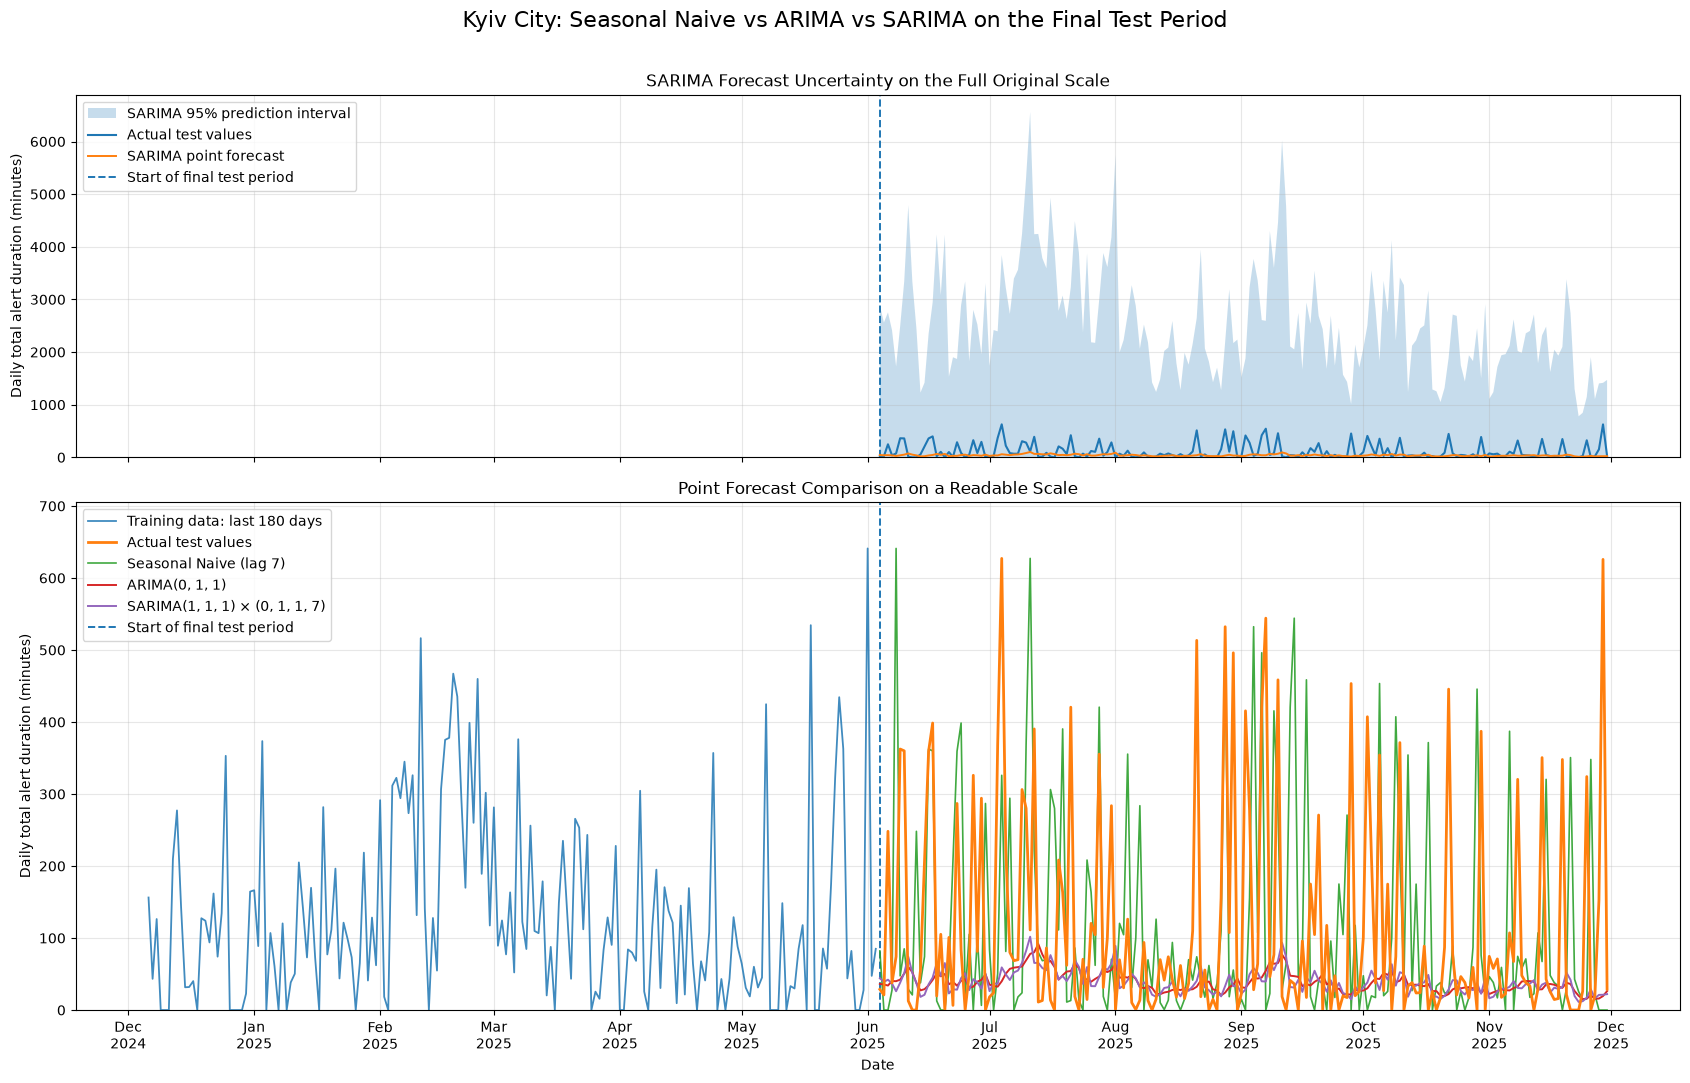

IMPROVED FINAL FORECAST COMPARISON FIGURE CREATED
Training history shown: 180 days
Training history period: 2024-12-06 to 2025-06-03
Final test period: 2025-06-04 to 2025-11-30
Point-forecast panel upper limit: 705.14 minutes

Saved figure:
D:\it10\PythonProject2\reports\figures\13_kyiv_city_seasonal_naive_arima_sarima.png


In [31]:
# =====================================================================
# Improved final forecast comparison figure:
# full SARIMA uncertainty + readable point forecasts
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ---------------------------------------------------------------------
# 1. Paths and settings
# ---------------------------------------------------------------------

PREDICTIONS_FILE = config.ARIMA_SARIMA_TEST_PREDICTIONS_FILE
FORECAST_FIGURE_FILE = config.KYIV_CITY_FORECAST_COMPARISON_FIGURE

TRAIN_HISTORY_DAYS_TO_PLOT = 180


# ---------------------------------------------------------------------
# 2. Check that the required data already exist
# ---------------------------------------------------------------------

if "y_train_original" not in globals():
    raise RuntimeError(
        "y_train_original is missing. "
        "Run the classical-series preparation cell first."
    )

if "y_test_original" not in globals():
    raise RuntimeError(
        "y_test_original is missing. "
        "Run the classical-series preparation cell first."
    )

if not PREDICTIONS_FILE.exists():
    raise FileNotFoundError(
        "Prediction file was not found:\n"
        f"{PREDICTIONS_FILE}\n\n"
        "Run the final ARIMA / SARIMA forecasting cell first."
    )


# ---------------------------------------------------------------------
# 3. Load final test predictions
# ---------------------------------------------------------------------

forecast_comparison = pd.read_csv(
    PREDICTIONS_FILE,
    parse_dates=["date"],
)

forecast_comparison = (
    forecast_comparison
    .sort_values("date")
    .reset_index(drop=True)
)

required_prediction_columns = {
    "date",
    "actual_duration_min",
    "seasonal_naive_duration_min",
    "arima_duration_min",
    "sarima_duration_min",
    "sarima_lower_95_min",
    "sarima_upper_95_min",
}

missing_columns = (
    required_prediction_columns
    - set(forecast_comparison.columns)
)

if missing_columns:
    raise KeyError(
        "The prediction CSV is missing required columns:\n"
        f"{sorted(missing_columns)}"
    )

if not forecast_comparison["date"].equals(
    pd.Series(y_test_original.index)
):
    raise ValueError(
        "Prediction dates do not match the final test period."
    )

if (
    forecast_comparison["sarima_lower_95_min"]
    > forecast_comparison["sarima_upper_95_min"]
).any():
    raise ValueError(
        "Some SARIMA lower interval bounds exceed upper bounds."
    )


# ---------------------------------------------------------------------
# 4. Select the last 180 days of training history
# ---------------------------------------------------------------------

train_history_to_plot = y_train_original.tail(
    TRAIN_HISTORY_DAYS_TO_PLOT
)

test_start_date = forecast_comparison["date"].min()

if train_history_to_plot.index.max() >= test_start_date:
    raise ValueError(
        "Training history overlaps with the test period."
    )


# ---------------------------------------------------------------------
# 5. Calculate a readable vertical scale for point forecasts
# ---------------------------------------------------------------------

point_forecast_values = np.concatenate(
    [
        train_history_to_plot.to_numpy(),
        forecast_comparison["actual_duration_min"].to_numpy(),
        forecast_comparison[
            "seasonal_naive_duration_min"
        ].to_numpy(),
        forecast_comparison["arima_duration_min"].to_numpy(),
        forecast_comparison["sarima_duration_min"].to_numpy(),
    ]
)

zoom_y_max = float(
    np.nanmax(point_forecast_values) * 1.10
)

if zoom_y_max <= 0:
    zoom_y_max = 1.0


# ---------------------------------------------------------------------
# 6. Create one figure with two panels
# ---------------------------------------------------------------------

FORECAST_FIGURE_FILE.parent.mkdir(
    parents=True,
    exist_ok=True,
)

fig, (axis_interval, axis_forecast) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(17, 11),
    sharex=True,
    gridspec_kw={
        "height_ratios": [1.0, 1.4],
    },
)


# ---------------------------------------------------------------------
# Top panel:
# "SARIMA 95% Prediction Interval on the Full Original Scale"
# ---------------------------------------------------------------------

axis_interval.fill_between(
    forecast_comparison["date"],
    forecast_comparison["sarima_lower_95_min"],
    forecast_comparison["sarima_upper_95_min"],
    alpha=0.25,
    label="SARIMA 95% prediction interval",
    zorder=1,
)

axis_interval.plot(
    forecast_comparison["date"],
    forecast_comparison["actual_duration_min"],
    label="Actual test values",
    linewidth=1.5,
    zorder=3,
)

axis_interval.plot(
    forecast_comparison["date"],
    forecast_comparison["sarima_duration_min"],
    label="SARIMA point forecast",
    linewidth=1.4,
    zorder=4,
)

axis_interval.axvline(
    test_start_date,
    linestyle="--",
    linewidth=1.4,
    label="Start of final test period",
)

axis_interval.set_title(
    "SARIMA Forecast Uncertainty on the Full Original Scale"
)

axis_interval.set_ylabel(
    "Daily total alert duration (minutes)"
)

axis_interval.set_ylim(bottom=0)

axis_interval.grid(
    True,
    alpha=0.3,
)

axis_interval.legend(
    loc="upper left",
    frameon=True,
)


# ---------------------------------------------------------------------
# Bottom panel:
# readable comparison of all point forecasts
# ---------------------------------------------------------------------

axis_forecast.plot(
    train_history_to_plot.index,
    train_history_to_plot.to_numpy(),
    label="Training data: last 180 days",
    linewidth=1.3,
    alpha=0.85,
    zorder=2,
)

axis_forecast.plot(
    forecast_comparison["date"],
    forecast_comparison["actual_duration_min"],
    label="Actual test values",
    linewidth=2.0,
    zorder=6,
)

axis_forecast.plot(
    forecast_comparison["date"],
    forecast_comparison["seasonal_naive_duration_min"],
    label="Seasonal Naive (lag 7)",
    linewidth=1.2,
    alpha=0.9,
    zorder=3,
)

axis_forecast.plot(
    forecast_comparison["date"],
    forecast_comparison["arima_duration_min"],
    label="ARIMA(0, 1, 1)",
    linewidth=1.4,
    zorder=4,
)

axis_forecast.plot(
    forecast_comparison["date"],
    forecast_comparison["sarima_duration_min"],
    label="SARIMA(1, 1, 1) × (0, 1, 1, 7)",
    linewidth=1.4,
    zorder=5,
)

axis_forecast.axvline(
    test_start_date,
    linestyle="--",
    linewidth=1.4,
    label="Start of final test period",
)

axis_forecast.set_title(
    "Point Forecast Comparison on a Readable Scale"
)

axis_forecast.set_xlabel("Date")

axis_forecast.set_ylabel(
    "Daily total alert duration (minutes)"
)

axis_forecast.set_ylim(
    bottom=0,
    top=zoom_y_max,
)

axis_forecast.grid(
    True,
    alpha=0.3,
)

axis_forecast.legend(
    loc="upper left",
    frameon=True,
)


# ---------------------------------------------------------------------
# 7. Date formatting and saving
# ---------------------------------------------------------------------

axis_forecast.xaxis.set_major_locator(
    mdates.MonthLocator(interval=1)
)

axis_forecast.xaxis.set_major_formatter(
    mdates.DateFormatter("%b\n%Y")
)

fig.suptitle(
    "Kyiv City: Seasonal Naive vs ARIMA vs SARIMA "
    "on the Final Test Period",
    fontsize=16,
)

fig.tight_layout(
    rect=(0, 0, 1, 0.97)
)

fig.savefig(
    FORECAST_FIGURE_FILE,
    dpi=180,
    bbox_inches="tight",
)

plt.show()


# ---------------------------------------------------------------------
# 8. Final output
# ---------------------------------------------------------------------

assert FORECAST_FIGURE_FILE.exists()

print("=" * 78)
print("IMPROVED FINAL FORECAST COMPARISON FIGURE CREATED")
print("=" * 78)

print(
    f"Training history shown: "
    f"{len(train_history_to_plot)} days"
)

print(
    "Training history period: "
    f"{train_history_to_plot.index.min().date()} "
    f"to {train_history_to_plot.index.max().date()}"
)

print(
    "Final test period: "
    f"{forecast_comparison['date'].min().date()} "
    f"to {forecast_comparison['date'].max().date()}"
)

print(
    f"Point-forecast panel upper limit: "
    f"{zoom_y_max:.2f} minutes"
)

print("\nSaved figure:")
print(FORECAST_FIGURE_FILE)

### Final forecast comparison

The final 180-day test period from 2025-06-04 to 2025-11-30 was not used during ARIMA or SARIMA order selection. Model orders were selected only with expanding validation folds inside the training period. All final forecasts were generated in a one-step-ahead walk-forward setting: for each day, the model used only observations available before that day.

ARIMA(0, 1, 1) achieved the lowest final test MAE of 100.338 minutes. SARIMA(1, 1, 1) × (0, 1, 1, 7) had a very similar MAE of 101.104 minutes, but weekly seasonal differencing did not improve the result relative to the simpler ARIMA model. Ridge Regression had a higher MAE of 111.104 minutes but the lowest RMSE of 150.887 minutes, indicating relatively better control of several large forecast errors. Seasonal Naive was the weakest model, with MAE equal to 134.345 minutes.

Therefore, ARIMA(0, 1, 1) was selected as the best model according to the main MAE criterion. However, all models have difficulty predicting abrupt increases in alert duration because the time series is affected by external events that are not represented by historical duration values and calendar features alone. The wide SARIMA 95% prediction interval further demonstrates this uncertainty.


In [32]:
import pandas as pd

metrics_check = pd.read_csv(config.FORECAST_METRICS_FILE)

display(
    metrics_check[
        [
            "model",
            "mae_min",
            "rmse_min",
            "smape_percent",
        ]
    ].round(3)
)

,model,mae_min,rmse_min,smape_percent
0,"ARIMA(0, 1, 1)",100.338,168.680,106.441
1,"SARIMA(1, 1, 1)x(0, 1, 1, 7)",101.104,168.314,108.176
2,Ridge Regression (alpha=1000.0),111.104,150.887,106.666
3,Seasonal Naive (lag 7),134.345,198.484,124.905
